# Physically Consistent Deep Learning



In [ ]:
import torch
from torch.func import jacrev, hessian, vmap
import matplotlib.pyplot as plt
import time
import numpy as np

## Task 1: ODE solution

Find $y(x)$ that satisfies $\mathcal{N}[y,x] = \frac{d^2 y}{d x^2} + y = 0$

### Prepare Data

We first prepare a dataset $\{(x,y)\}$ that satisfies the DE
The dataset has very few datapoints (to test data efficiency) and with noise (to test robustness)

In [ ]:
# Generation of synthetic dataset
def generate_data(interval = (-torch.pi, torch.pi), num_samples= 1000, A = 1.0, phi = 0.0):
  X = (interval[1]-interval[0]) * torch.rand((num_samples, 1), requires_grad= True) + interval[0]

  f = lambda x : A*torch.cos(x + phi)
  Y = f(X)
  print(f"Generated dataset with {num_samples} samples, x in interval [{X.min().item():.2f}, {X.max().item():.2f}], y(x) = {A:.2f} cos(x {phi:+.2f})")

  # check if the differential equation N[y,x] = 0 holds

  ## compute first derivative (jacobian)
  df_dx = vmap(jacrev(f))
  dY_dX = df_dx(X).reshape(Y.shape)

  ## compute second derivative (hessian)
  d2f_dx2 = vmap(hessian(f))
  d2Y_dX2 = d2f_dx2(X).reshape(Y.shape)

  ## compute N[y,x]
  N = d2Y_dX2 + Y
  if torch.allclose(torch.mean(torch.square(N)), torch.tensor(0.)) :
    print("Differential equation holds")
  else:
    print("Something went wrong, Differential equation doesn't hold")
  return (X,Y)

def generate_train_test(interval_train, num_samples_train, interval_test, num_samples_test):
  A = 3* torch.rand(()) + 1 # random number between [1, 4]
  phi = 2 * torch.pi * torch.rand(()) - torch.pi # random number between [-pi, pi]
  return generate_data(interval_train, num_samples_train, A, phi), generate_data(interval_test, num_samples_test, A, phi)


# very few data points + noise
# range of test data is wider to test generalization to unseen scenarios
# 50 points for training |
(X_train, Y_train), (X_test, Y_test) = generate_train_test([-5, 5], 50, [-10, 10], 1000)
X_train += 0.1 * torch.randn_like(X_train)
Y_train += 0.1 * torch.randn_like(Y_train)

print(f"Training data shape: {X_train.shape}, {Y_train.shape}")
print(f"Test data shape: {X_test.shape}, {Y_test.shape}")

Generated dataset with 50 samples, x in interval [-4.88, 4.60], y(x) = 3.34 cos(x +1.48)
Differential equation holds
Generated dataset with 1000 samples, x in interval [-9.99, 9.97], y(x) = 3.34 cos(x +1.48)
Differential equation holds
Training data shape: torch.Size([50, 1]), torch.Size([50, 1])
Test data shape: torch.Size([1000, 1]), torch.Size([1000, 1])


### Prepare the model $f_{NN}(x; \theta)$ and its derivatives


- `vmap` is the vectorization map operator, it takes a function and gives a batched version of the same function. If $f: \mathbb{R} \rightarrow \mathbb{R}$. Then $\text{vmap}(f) =  f' : \mathbb{R^{n}} → \mathbb{R^{n}}$
- `jacrev` is the jacobian operator (using reverse autograd), it takes a function $f(x)$ and gives a function $\frac{\partial f}{\partial x} (x)$.
- `hessian` is the hessian operator, it takes a function $f(x)$ and gives a function $\frac{\partial^2 f}{\partial x^2} (x)$.

These functions are part of the functional API of PyTorch that is similar to JAX.

In [ ]:
def get_model_and_derivatives(hidden_channels = (64, 64), activation = torch.nn.GELU, device= "cpu"):
  # construct a simple MLP
  layers = []
  inp = 1
  for h in hidden_channels:
      layers.append(torch.nn.Linear(inp, h))
      layers.append(activation())
      inp = h
  layers.append(torch.nn.Linear(inp, 1))
  model =  torch.nn.Sequential(*layers).to(device)

  # functions to compute the output and its derivatives
  # we use functions because jacrev, hessian, vmap ... requires a function and not nn.Module
  # that's why the API is called "functional"
  f = lambda x : model(x)
  df_dx = vmap(jacrev(f))
  d2f_dx2 = vmap(hessian(f))

  return (f, df_dx, d2f_dx2), model.parameters()

### Testing routine

In [ ]:
def test_model(f, X, Y):
  # simple check for f(X) vs Y,
  print(f"MSE: {torch.nn.functional.mse_loss(f(X), Y)}")
  sorted_indices = torch.argsort(X.flatten())
  X = X[sorted_indices].reshape(-1,1)
  Y = Y[sorted_indices].reshape(-1,1)
  plt.plot(X.detach().cpu(), Y.detach().cpu(), label= 'Act')
  plt.plot(X.detach().cpu(), f(X).detach().cpu(), label= 'Pred')
  plt.legend()
  plt.plot()

### Train a black-box deep learning model

t: 0.14, Epoch 100: MSE: 0.0580, LR: 0.009649
t: 0.28, Epoch 200: MSE: 0.0470, LR: 0.008644
t: 0.45, Epoch 300: MSE: 0.0438, LR: 0.007127
t: 0.59, Epoch 400: MSE: 0.0420, LR: 0.005311
t: 0.73, Epoch 500: MSE: 0.0404, LR: 0.003451
t: 0.87, Epoch 600: MSE: 0.0392, LR: 0.001809
t: 1.01, Epoch 700: MSE: 0.0386, LR: 0.000616
t: 1.15, Epoch 800: MSE: 0.0385, LR: 0.000039
t: 1.30, Epoch 900: MSE: 0.0384, LR: 0.000159
t: 1.46, Epoch 1000: MSE: 0.0381, LR: 0.000959
t: 1.60, Epoch 1100: MSE: 0.0370, LR: 0.002328
t: 1.74, Epoch 1200: MSE: 0.0378, LR: 0.004072
t: 1.87, Epoch 1300: MSE: 0.0334, LR: 0.005947
t: 2.01, Epoch 1400: MSE: 0.0327, LR: 0.007688
t: 2.15, Epoch 1500: MSE: 0.0333, LR: 0.009052
t: 2.29, Epoch 1600: MSE: 0.0319, LR: 0.009846
t: 2.44, Epoch 1700: MSE: 0.0315, LR: 0.009959
t: 2.59, Epoch 1800: MSE: 0.0312, LR: 0.009375
t: 2.73, Epoch 1900: MSE: 0.0308, LR: 0.008176
t: 2.86, Epoch 2000: MSE: 0.0305, LR: 0.006531
t: 3.00, Epoch 2100: MSE: 0.0303, LR: 0.004670
t: 3.14, Epoch 2200: M

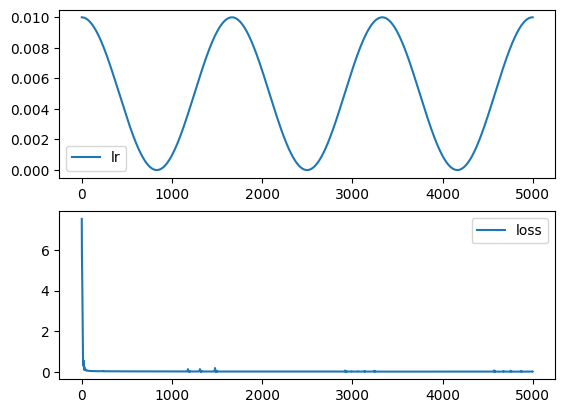

In [ ]:
lr = 0.01
num_epochs = 5000
T_scheduler = num_epochs // 6
device = "cpu"
loss_fun = torch.nn.MSELoss()

(f, _, _), params = get_model_and_derivatives(device=device)
optim = torch.optim.Adam(params, lr= lr)
# We use a CosineAnnealingLR scheduler to help avoid local minima
# it helps excite the training process which could pull the weights from
# a gradient local minima

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optim, T_scheduler)

lrs = []
losses = []

X_train = X_train.to(device)
Y_train = Y_train.to(device)
X_test = X_test.to(device)
Y_test = Y_test.to(device)

start_time = time.time()
for epoch in range(num_epochs):
  optim.zero_grad()

  Y_pred = f(X_train)
  loss_mse = loss_fun(Y_train, Y_pred)
  loss = loss_mse
  loss.backward(retain_graph= True)
  optim.step()
  scheduler.step()
  lrs.append(scheduler.get_last_lr()[0])
  losses.append(loss.item())
  if (epoch + 1)%100 == 0:
    print(f"t: {time.time()-start_time:.2f}, Epoch {epoch+1}: MSE: {loss_mse.item():.4f}, LR: {scheduler.get_last_lr()[0]:.6f}")

plt.subplot(2, 1, 1)
plt.plot(lrs, label= 'lr')
plt.legend()
plt.subplot(2, 1, 2)
plt.plot(losses, label= 'loss')
plt.legend()
plt.show()


MSE: 0.03072645142674446


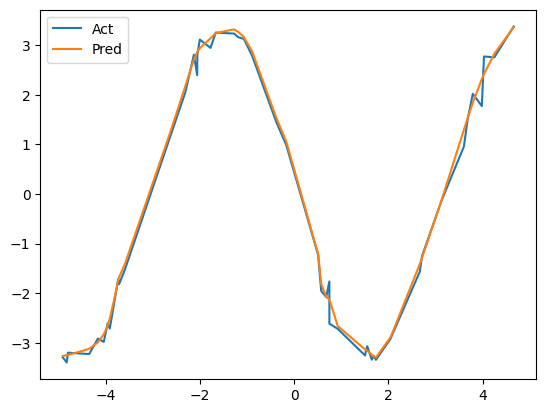

In [ ]:
test_model(f, X_train, Y_train)

MSE: 24.25082015991211


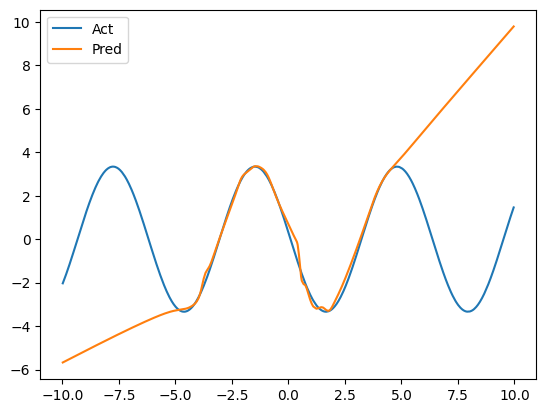

In [ ]:
test_model(f, X_test, Y_test)

We can see signs for overfitting and poor generlization

### Train a PINN deep learning model

t: 0.95, Epoch 100: MSE: 0.0437, Phys: 0.0147, LR: 0.003419
t: 1.93, Epoch 200: MSE: 0.0421, Phys: 0.0038, LR: 0.001000
t: 2.86, Epoch 300: MSE: 0.0437, Phys: 0.0018, LR: 0.009111
t: 3.82, Epoch 400: MSE: 0.0417, Phys: 0.0009, LR: 0.006400
t: 4.76, Epoch 500: MSE: 0.0416, Phys: 0.0009, LR: 0.000004
t: 5.71, Epoch 600: MSE: 0.0416, Phys: 0.0009, LR: 0.006759
t: 6.65, Epoch 700: MSE: 0.0415, Phys: 0.0019, LR: 0.008884
t: 7.59, Epoch 800: MSE: 0.0414, Phys: 0.0013, LR: 0.000784
t: 8.74, Epoch 900: MSE: 0.0413, Phys: 0.0013, LR: 0.003782
t: 10.04, Epoch 1000: MSE: 0.0412, Phys: 0.0012, LR: 0.009986


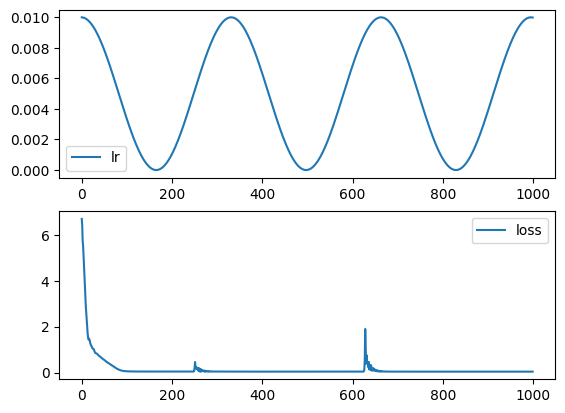

In [ ]:
lr = 0.01
num_epochs = 1000
T_scheduler = num_epochs // 6
coeff_phys = 1.0
device = "cpu"
loss_fun = torch.nn.MSELoss()

(f, _, d2f_dx2), params = get_model_and_derivatives(device=device)
optim = torch.optim.Adam(params, lr= lr)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optim, T_scheduler)

lrs = []
losses_mse = []
losses_phys = []
losses = []

X_train = X_train.to(device)
Y_train = Y_train.to(device)
X_test = X_test.to(device)
Y_test = Y_test.to(device)

start_time = time.time()
for epoch in range(num_epochs):
  optim.zero_grad()
  Y_pred = f(X_train)
  loss_mse = loss_fun(Y_train, Y_pred)


  # we add a loss function for the constraint d2y_dx2 - y = 0
  d2Y_dX2_pred = d2f_dx2(X_train).reshape(-1,1)
  loss_phys = loss_fun(d2Y_dX2_pred, -Y_pred)
  #
  loss = loss_mse + coeff_phys * loss_phys
  loss.backward(retain_graph= True)
  optim.step()
  scheduler.step()
  lrs.append(scheduler.get_last_lr()[0])
  losses_mse.append(loss_mse.item())
  losses_phys.append(loss_phys.item())
  losses.append(loss.item())
  if (epoch + 1)%100 == 0:
    print(f"t: {time.time() - start_time:.2f}, Epoch {epoch+1}: MSE: {loss_mse.item():.4f}, Phys: {loss_phys.item():.4f}, LR: {scheduler.get_last_lr()[0]:.6f}")

plt.subplot(2, 1, 1)
plt.plot(lrs, label= 'lr')
plt.legend()
plt.subplot(2, 1, 2)
plt.plot(losses, label= 'loss')
plt.legend()
plt.show()


MSE: 0.041238799691200256


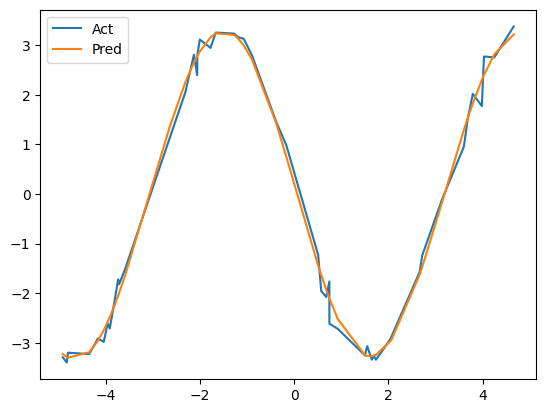

In [ ]:
test_model(f, X_train, Y_train)

MSE: 2.5464231967926025


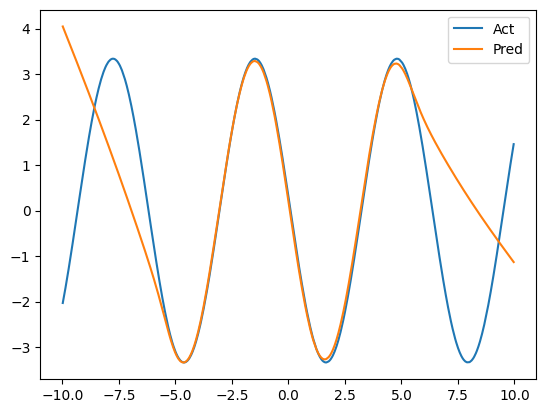

In [ ]:
test_model(f, X_test, Y_test)

We can already see that the physica loss has regulerization effect, even with noisy data, the physical constraint decreased overfitting

### Train a PINN deep learning model - 2nd try

We will use extra data points $x$ that we don't $y$ for. However, we know that $\frac{\partial^2 f}{\partial x^2}(x) - f(x) = 0$  

t: 3.73, Epoch: 100: MSE: 0.1459, Phys1: 0.0365,Phys2: 0.5793,  LR: 0.009649
t: 7.51, Epoch: 200: MSE: 0.1337, Phys1: 0.0286,Phys2: 0.5086,  LR: 0.008644
t: 12.00, Epoch: 300: MSE: 0.1174, Phys1: 0.0210,Phys2: 0.4591,  LR: 0.007127
t: 15.95, Epoch: 400: MSE: 0.1037, Phys1: 0.0161,Phys2: 0.3893,  LR: 0.005311
t: 19.81, Epoch: 500: MSE: 0.0881, Phys1: 0.0166,Phys2: 0.2847,  LR: 0.003451
t: 24.04, Epoch: 600: MSE: 0.0772, Phys1: 0.0143,Phys2: 0.2179,  LR: 0.001809
t: 28.01, Epoch: 700: MSE: 0.0727, Phys1: 0.0133,Phys2: 0.1897,  LR: 0.000616
t: 31.87, Epoch: 800: MSE: 0.0716, Phys1: 0.0130,Phys2: 0.1835,  LR: 0.000039
t: 36.05, Epoch: 900: MSE: 0.0715, Phys1: 0.0129,Phys2: 0.1826,  LR: 0.000159
t: 40.16, Epoch: 1000: MSE: 0.0694, Phys1: 0.0124,Phys2: 0.1712,  LR: 0.000959
t: 43.95, Epoch: 1100: MSE: 0.0690, Phys1: 0.0112,Phys2: 0.1472,  LR: 0.002328
t: 48.06, Epoch: 1200: MSE: 0.0620, Phys1: 0.0113,Phys2: 0.1222,  LR: 0.004072
t: 52.30, Epoch: 1300: MSE: 0.0575, Phys1: 0.0104,Phys2: 0.1128

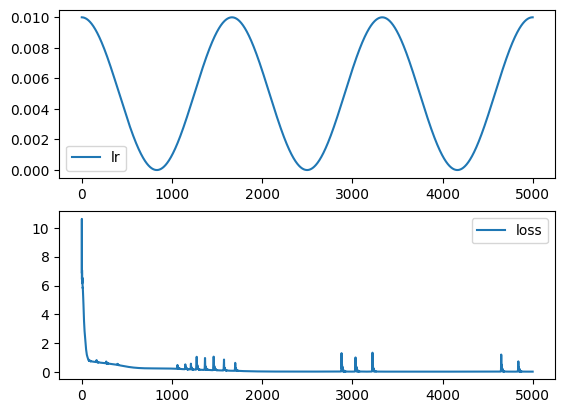

In [ ]:
lr = 0.01
num_epochs = 5000
T_scheduler = num_epochs // 6
coeff_phys1 = 1.0
coeff_phys2 = 1.0
device = "cpu"
loss_fun = torch.nn.MSELoss()

(f, _, d2f_dx2), params = get_model_and_derivatives(device=device)
optim = torch.optim.Adam(params, lr= lr)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optim, T_scheduler)

lrs = []
losses_mse = []
losses_phys = []
losses = []

X_train = X_train.to(device)
Y_train = Y_train.to(device)
X_test = X_test.to(device)
Y_test = Y_test.to(device)

# dummy data in [-10, 10] interval
X_dummy = torch.arange(-10, 10, 0.01).to(device).reshape(-1,1)

start_time = time.time()
for epoch in range(num_epochs):
  optim.zero_grad()
  Y_pred = f(X_train)
  d2Y_dX2_pred = d2f_dx2(X_train).reshape(-1,1)
  loss_mse = loss_fun(Y_train, Y_pred)
  loss_phys1 = loss_fun(d2Y_dX2_pred, -Y_pred)

  # physics loss using dummy data (no Y available)
  Y_pred_dummy = f(X_dummy)
  d2Y_dX2_pred_dummy = d2f_dx2(X_dummy).reshape(-1,1)
  loss_phys2 = loss_fun(d2Y_dX2_pred_dummy, -Y_pred_dummy)

  loss = loss_mse + coeff_phys1 * loss_phys1 + coeff_phys2 * loss_phys2

  loss.backward(retain_graph= True)
  optim.step()
  scheduler.step()
  lrs.append(scheduler.get_last_lr()[0])
  losses_mse.append(loss_mse.item())
  losses_phys.append(loss_phys.item())
  losses.append(loss.item())
  if (epoch + 1)%100 == 0:
    print(f"t: {time.time() - start_time:.2f}, Epoch: {epoch+1}: MSE: {loss_mse.item():.4f}, Phys1: {loss_phys1.item():.4f},Phys2: {loss_phys2.item():.4f},  LR: {scheduler.get_last_lr()[0]:.6f}")

plt.subplot(2, 1, 1)
plt.plot(lrs, label= 'lr')
plt.legend()
plt.subplot(2, 1, 2)
plt.plot(losses, label= 'loss')
plt.legend()
plt.show()


MSE: 0.04215278476476669


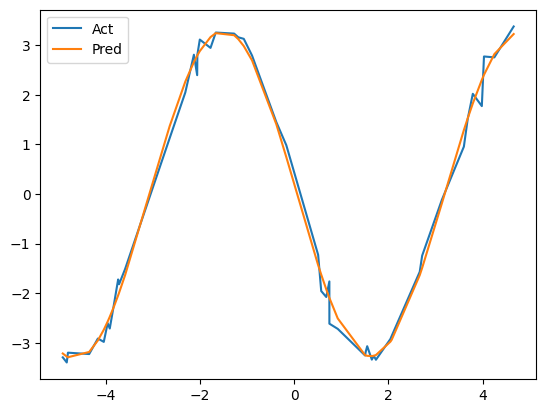

In [ ]:
test_model(f, X_train, Y_train)

MSE: 0.008741011843085289


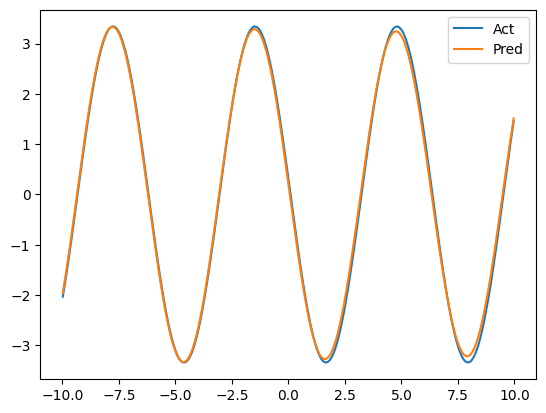

In [ ]:
test_model(f, X_test, Y_test)

We can see that even with only 50 noisy data points on [-5, 5] range, we are able to predict well outisde that range.

## HW 1:
Suggest other constraint that can be done using dummy data, something related to the periodic nature maybe?. Implement your suggestion and produce graphs. Comment on them


In [ ]:
# Generation of synthetic dataset
def generate_data(interval = (-torch.pi, torch.pi), num_samples= 1000, A = 1.0, phi = 0.0):
  X = (interval[1]-interval[0]) * torch.rand((num_samples, 1), requires_grad= True) + interval[0]

  f = lambda x : A*torch.cos(x + phi)
  Y = f(X)
  print(f"Generated dataset with {num_samples} samples, x in interval [{X.min().item():.2f}, {X.max().item():.2f}], y(x) = {A:.2f} cos(x {phi:+.2f})")

  # check if the differential equation N[y,x] = 0 holds

  ## compute first derivative (jacobian)
  df_dx = vmap(jacrev(f))
  dY_dX = df_dx(X).reshape(Y.shape)

  ## compute second derivative (hessian)
  d2f_dx2 = vmap(hessian(f))
  d2Y_dX2 = d2f_dx2(X).reshape(Y.shape)

  ## compute N[y,x]
  N = d2Y_dX2 + Y
  if torch.allclose(torch.mean(torch.square(N)), torch.tensor(0.)) :
    print("Differential equation holds")
  else:
    print("Something went wrong, Differential equation doesn't hold")
  return (X,Y)

def generate_train_test(interval_train, num_samples_train, interval_test, num_samples_test):
  A = 3* torch.rand(()) + 1 # random number between [1, 4]
  phi = 2 * torch.pi * torch.rand(()) - torch.pi # random number between [-pi, pi]
  return generate_data(interval_train, num_samples_train, A, phi), generate_data(interval_test, num_samples_test, A, phi)


# very few data points + noise
# range of test data is wider to test generalization to unseen scenarios
# 50 points for training |
(X_train, Y_train), (X_test, Y_test) = generate_train_test([-5, 5], 50, [-10, 10], 1000)
X_train += 0.1 * torch.randn_like(X_train)
Y_train += 0.1 * torch.randn_like(Y_train)

print(f"Training data shape: {X_train.shape}, {Y_train.shape}")
print(f"Test data shape: {X_test.shape}, {Y_test.shape}")

Generated dataset with 50 samples, x in interval [-4.58, 4.97], y(x) = 3.22 cos(x -0.37)
Differential equation holds
Generated dataset with 1000 samples, x in interval [-9.97, 9.96], y(x) = 3.22 cos(x -0.37)
Differential equation holds
Training data shape: torch.Size([50, 1]), torch.Size([50, 1])
Test data shape: torch.Size([1000, 1]), torch.Size([1000, 1])


In [ ]:
def get_model_and_derivatives(hidden_channels = (64, 64), activation = torch.nn.GELU, device= "cpu"):
  # construct a simple MLP
  layers = []
  inp = 1
  for h in hidden_channels:
      layers.append(torch.nn.Linear(inp, h))
      layers.append(activation())
      inp = h
  layers.append(torch.nn.Linear(inp, 1))
  model =  torch.nn.Sequential(*layers).to(device)

  # functions to compute the output and its derivatives
  # we use functions because jacrev, hessian, vmap ... requires a function and not nn.Module
  # that's why the API is called "functional"
  f = lambda x : model(x)
  df_dx = vmap(jacrev(f))
  d2f_dx2 = vmap(hessian(f))

  return (f, df_dx, d2f_dx2), model.parameters()

In [ ]:
def test_model(f, X, Y):
  # simple check for f(X) vs Y,
  print(f"MSE: {torch.nn.functional.mse_loss(f(X), Y)}")
  sorted_indices = torch.argsort(X.flatten())
  X = X[sorted_indices].reshape(-1,1)
  Y = Y[sorted_indices].reshape(-1,1)
  plt.plot(X.detach().cpu(), Y.detach().cpu(), label= 'Act')
  plt.plot(X.detach().cpu(), f(X).detach().cpu(), label= 'Pred')
  plt.legend()
  plt.plot()

t: 0.14, Epoch 100: MSE: 0.0573, LR: 0.009649
t: 0.28, Epoch 200: MSE: 0.0528, LR: 0.008644
t: 0.43, Epoch 300: MSE: 0.0518, LR: 0.007127
t: 0.58, Epoch 400: MSE: 0.0513, LR: 0.005311
t: 0.72, Epoch 500: MSE: 0.0508, LR: 0.003451
t: 0.86, Epoch 600: MSE: 0.0504, LR: 0.001809
t: 1.00, Epoch 700: MSE: 0.0502, LR: 0.000616
t: 1.15, Epoch 800: MSE: 0.0501, LR: 0.000039
t: 1.29, Epoch 900: MSE: 0.0501, LR: 0.000159
t: 1.44, Epoch 1000: MSE: 0.0500, LR: 0.000959
t: 1.58, Epoch 1100: MSE: 0.0496, LR: 0.002328
t: 1.73, Epoch 1200: MSE: 0.0490, LR: 0.004072
t: 1.87, Epoch 1300: MSE: 0.0497, LR: 0.005947
t: 2.01, Epoch 1400: MSE: 0.0792, LR: 0.007688
t: 2.15, Epoch 1500: MSE: 0.0473, LR: 0.009052
t: 2.29, Epoch 1600: MSE: 0.0487, LR: 0.009846
t: 2.42, Epoch 1700: MSE: 0.0464, LR: 0.009959
t: 2.58, Epoch 1800: MSE: 0.0457, LR: 0.009375
t: 2.72, Epoch 1900: MSE: 0.0448, LR: 0.008176
t: 2.86, Epoch 2000: MSE: 0.0439, LR: 0.006531
t: 3.00, Epoch 2100: MSE: 0.0431, LR: 0.004670
t: 3.14, Epoch 2200: M

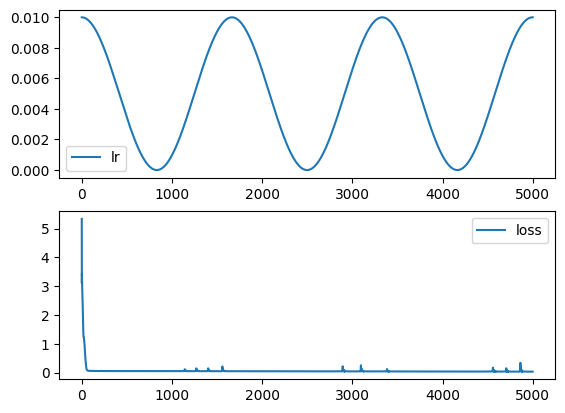

In [ ]:
lr = 0.01
num_epochs = 5000
T_scheduler = num_epochs // 6
device = "cpu"
loss_fun = torch.nn.MSELoss()

(f, _, _), params = get_model_and_derivatives(device=device)
optim = torch.optim.Adam(params, lr= lr)
# We use a CosineAnnealingLR scheduler to help avoid local minima
# it helps excite the training process which could pull the weights from
# a gradient local minima

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optim, T_scheduler)

lrs = []
losses = []

X_train = X_train.to(device)
Y_train = Y_train.to(device)
X_test = X_test.to(device)
Y_test = Y_test.to(device)

start_time = time.time()
for epoch in range(num_epochs):
  optim.zero_grad()

  Y_pred = f(X_train)
  loss_mse = loss_fun(Y_train, Y_pred)
  loss = loss_mse
  loss.backward(retain_graph= True)
  optim.step()
  scheduler.step()
  lrs.append(scheduler.get_last_lr()[0])
  losses.append(loss.item())
  if (epoch + 1)%100 == 0:
    print(f"t: {time.time()-start_time:.2f}, Epoch {epoch+1}: MSE: {loss_mse.item():.4f}, LR: {scheduler.get_last_lr()[0]:.6f}")

plt.subplot(2, 1, 1)
plt.plot(lrs, label= 'lr')
plt.legend()
plt.subplot(2, 1, 2)
plt.plot(losses, label= 'loss')
plt.legend()
plt.show()


MSE: 0.0318886861205101


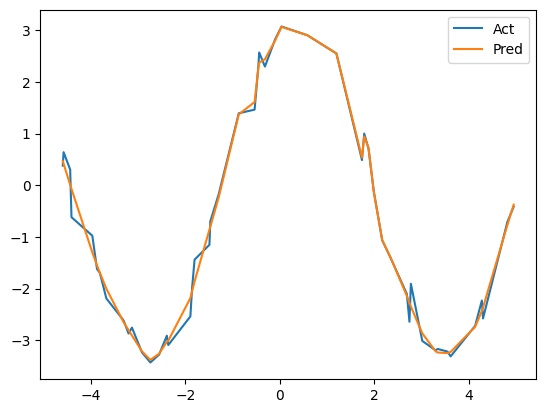

In [ ]:
test_model(f, X_train, Y_train)

MSE: 31.635913848876953


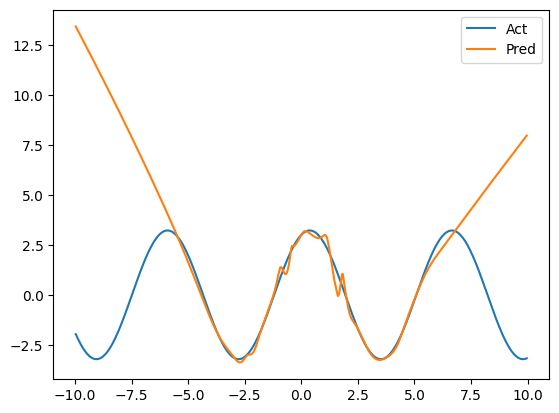

In [ ]:
test_model(f, X_test, Y_test)

t: 1.17, Epoch 100: MSE: 0.0647, Phys: 0.0035, LR: 0.003419
t: 2.39, Epoch 200: MSE: 0.0649, Phys: 0.0028, LR: 0.001000
t: 3.76, Epoch 300: MSE: 0.0705, Phys: 0.0131, LR: 0.009111
t: 4.80, Epoch 400: MSE: 0.0649, Phys: 0.0023, LR: 0.006400
t: 5.77, Epoch 500: MSE: 0.0649, Phys: 0.0023, LR: 0.000004
t: 6.74, Epoch 600: MSE: 0.0649, Phys: 0.0023, LR: 0.006759
t: 7.69, Epoch 700: MSE: 0.0673, Phys: 0.0015, LR: 0.008884
t: 8.64, Epoch 800: MSE: 0.0649, Phys: 0.0022, LR: 0.000784
t: 9.58, Epoch 900: MSE: 0.0649, Phys: 0.0022, LR: 0.003782
t: 10.51, Epoch 1000: MSE: 0.0649, Phys: 0.0021, LR: 0.009986


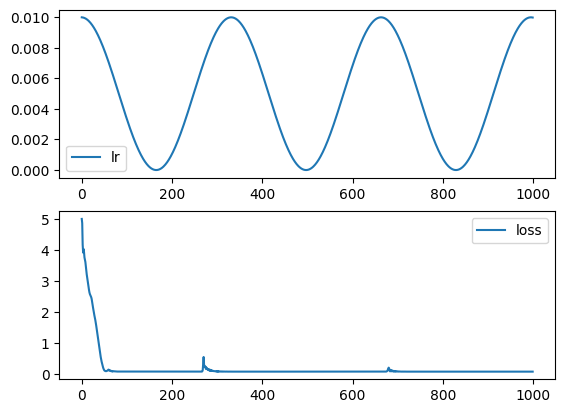

In [ ]:
lr = 0.01
num_epochs = 1000
T_scheduler = num_epochs // 6
coeff_phys = 1.0
device = "cpu"
loss_fun = torch.nn.MSELoss()

(f, _, d2f_dx2), params = get_model_and_derivatives(device=device)
optim = torch.optim.Adam(params, lr= lr)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optim, T_scheduler)

lrs = []
losses_mse = []
losses_phys = []
losses = []

X_train = X_train.to(device)
Y_train = Y_train.to(device)
X_test = X_test.to(device)
Y_test = Y_test.to(device)

start_time = time.time()
for epoch in range(num_epochs):
  optim.zero_grad()
  Y_pred = f(X_train)
  loss_mse = loss_fun(Y_train, Y_pred)


  # we add a loss function for the constraint d2y_dx2 - y = 0
  d2Y_dX2_pred = d2f_dx2(X_train).reshape(-1,1)
  loss_phys = loss_fun(d2Y_dX2_pred, -Y_pred)
  #
  loss = loss_mse + coeff_phys * loss_phys
  loss.backward(retain_graph= True)
  optim.step()
  scheduler.step()
  lrs.append(scheduler.get_last_lr()[0])
  losses_mse.append(loss_mse.item())
  losses_phys.append(loss_phys.item())
  losses.append(loss.item())
  if (epoch + 1)%100 == 0:
    print(f"t: {time.time() - start_time:.2f}, Epoch {epoch+1}: MSE: {loss_mse.item():.4f}, Phys: {loss_phys.item():.4f}, LR: {scheduler.get_last_lr()[0]:.6f}")

plt.subplot(2, 1, 1)
plt.plot(lrs, label= 'lr')
plt.legend()
plt.subplot(2, 1, 2)
plt.plot(losses, label= 'loss')
plt.legend()
plt.show()


MSE: 0.06492561846971512


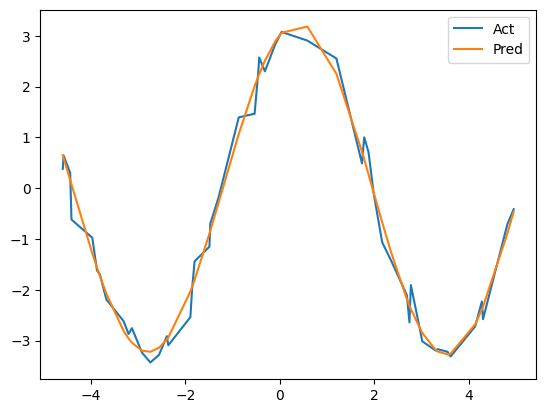

In [ ]:
test_model(f, X_train, Y_train)

MSE: 42.15484619140625


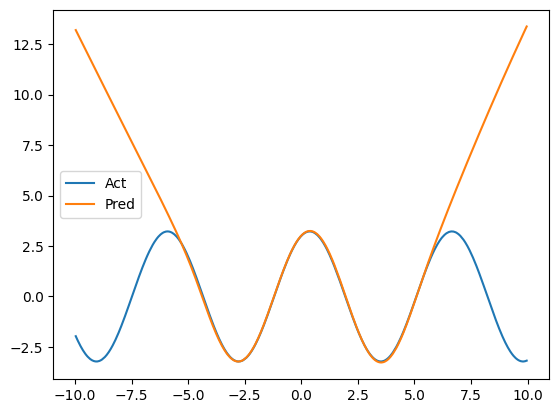

In [ ]:
test_model(f, X_test, Y_test)

/tmp/ipython-input-3861888745.py:51: FutureWarning: We've integrated functorch into PyTorch. As the final step of the integration, `functorch.jacrev` is deprecated as of PyTorch 2.0 and will be deleted in a future version of PyTorch >= 2.3. Please use `torch.func.jacrev` instead; see the PyTorch 2.0 release notes and/or the `torch.func` migration guide for more details https://pytorch.org/docs/main/func.migrating.html
  dy_dx = vmap(jacrev(f))
/tmp/ipython-input-3861888745.py:51: FutureWarning: We've integrated functorch into PyTorch. As the final step of the integration, `functorch.vmap` is deprecated as of PyTorch 2.0 and will be deleted in a future version of PyTorch >= 2.3. Please use `torch.vmap` instead; see the PyTorch 2.0 release notes and/or the `torch.func` migration guide for more details https://pytorch.org/docs/main/func.migrating.html
  dy_dx = vmap(jacrev(f))


t: 2.42, Epoch: 100: MSE: 0.3344, Phys1: 0.2941, Phys2: 0.3393, Periodic: 0.0009, LR: 0.009649
t: 5.52, Epoch: 200: MSE: 0.1152, Phys1: 0.0626, Phys2: 0.2335, Periodic: 0.0121, LR: 0.008644
t: 7.96, Epoch: 300: MSE: 0.0890, Phys1: 0.0321, Phys2: 0.1664, Periodic: 0.0223, LR: 0.007127
t: 10.40, Epoch: 400: MSE: 0.0760, Phys1: 0.0192, Phys2: 0.1412, Periodic: 0.0013, LR: 0.005311
t: 12.79, Epoch: 500: MSE: 0.0734, Phys1: 0.0170, Phys2: 0.1342, Periodic: 0.0014, LR: 0.003451
t: 15.24, Epoch: 600: MSE: 0.0724, Phys1: 0.0161, Phys2: 0.1295, Periodic: 0.0015, LR: 0.001809
t: 18.26, Epoch: 700: MSE: 0.0721, Phys1: 0.0157, Phys2: 0.1270, Periodic: 0.0016, LR: 0.000616
t: 20.65, Epoch: 800: MSE: 0.0720, Phys1: 0.0157, Phys2: 0.1263, Periodic: 0.0016, LR: 0.000039
t: 23.11, Epoch: 900: MSE: 0.0720, Phys1: 0.0157, Phys2: 0.1262, Periodic: 0.0016, LR: 0.000159
t: 25.54, Epoch: 1000: MSE: 0.0718, Phys1: 0.0155, Phys2: 0.1247, Periodic: 0.0016, LR: 0.000959
t: 28.14, Epoch: 1100: MSE: 0.0713, Phys1:

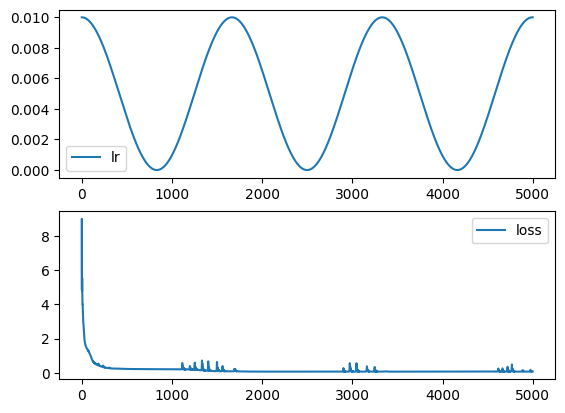

In [ ]:
lr = 0.01
num_epochs = 5000
T_scheduler = num_epochs // 6
coeff_phys1 = 1.0
coeff_phys2 = 1.0
coeff_periodic = 0.5   # weight for periodic constraint
device = "cpu"
loss_fun = torch.nn.MSELoss()

(f, _, d2f_dx2), params = get_model_and_derivatives(device=device)
optim = torch.optim.Adam(params, lr=lr)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optim, T_scheduler)

lrs = []
losses_mse = []
losses_phys = []
losses = []

X_train = X_train.to(device)
Y_train = Y_train.to(device)
X_test = X_test.to(device)
Y_test = Y_test.to(device)

# dummy data in [-10, 10] interval
X_dummy = torch.arange(-10, 10, 0.1).to(device).reshape(-1, 1)

start_time = time.time()
for epoch in range(num_epochs):
    optim.zero_grad()

    # Predictions and derivatives
    Y_pred = f(X_train)
    d2Y_dX2_pred = d2f_dx2(X_train).reshape(-1, 1)

    # Main losses
    loss_mse = loss_fun(Y_train, Y_pred)
    loss_phys1 = loss_fun(d2Y_dX2_pred, -Y_pred)

    # Physics loss using dummy data (no Y available)
    Y_pred_dummy = f(X_dummy)
    d2Y_dX2_pred_dummy = d2f_dx2(X_dummy).reshape(-1, 1)
    loss_phys2 = loss_fun(d2Y_dX2_pred_dummy, -Y_pred_dummy)

    # --- Periodic physical constraint ---
    x_left = torch.tensor([[-torch.pi]], device=device)
    x_right = torch.tensor([[torch.pi]], device=device)
    y_left = f(x_left)
    y_right = f(x_right)

    from functorch import vmap, jacrev
    dy_dx = vmap(jacrev(f))
    dy_left = dy_dx(x_left)
    dy_right = dy_dx(x_right)

    loss_periodic = loss_fun(y_left, y_right) + loss_fun(dy_left, dy_right)
    # -------------------------------------

    # Total loss with all physics-based constraints
    loss = (loss_mse +
            coeff_phys1 * loss_phys1 +
            coeff_phys2 * loss_phys2 +
            coeff_periodic * loss_periodic)

    # Backpropagation
    loss.backward(retain_graph=True)
    optim.step()
    scheduler.step()

    # Track metrics
    lrs.append(scheduler.get_last_lr()[0])
    losses_mse.append(loss_mse.item())
    losses_phys.append(loss_phys1.item())
    losses.append(loss.item())

    # Logging
    if (epoch + 1) % 100 == 0:
        print(f"t: {time.time() - start_time:.2f}, Epoch: {epoch+1}: "
              f"MSE: {loss_mse.item():.4f}, Phys1: {loss_phys1.item():.4f}, "
              f"Phys2: {loss_phys2.item():.4f}, Periodic: {loss_periodic.item():.4f}, "
              f"LR: {scheduler.get_last_lr()[0]:.6f}")

# Plot learning rate and loss trends
plt.subplot(2, 1, 1)
plt.plot(lrs, label='lr')
plt.legend()
plt.subplot(2, 1, 2)
plt.plot(losses, label='loss')
plt.legend()
plt.show()


MSE: 0.06986693292856216


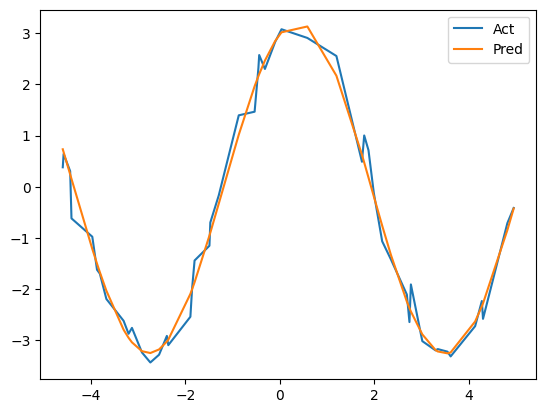

In [ ]:
test_model(f, X_train, Y_train)

MSE: 0.003246172796934843


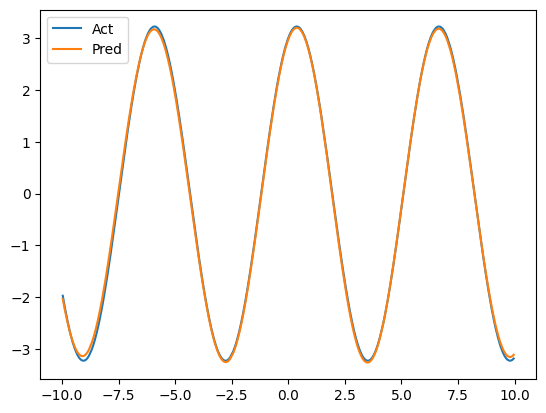

In [ ]:
test_model(f, X_test, Y_test)

## ODE discovery
Find $y(x)$ that satisfies $\mathcal{N}[y,x; \omega] = \frac{d^2 y}{d x^2} + \omega ^2 y = 0$, $\omega$ is unknown

### Prepare Data

As before, but with different frequency $\omega = 1.5$ is unknown to the model, it should be learnt

In [ ]:
# Generation of synthetic dataset
def generate_data(interval = (-torch.pi, torch.pi), num_samples= 1000, A = 1.0, phi = 0.0, omega= 1.5):
  X = (interval[1]-interval[0]) * torch.rand((num_samples, 1), requires_grad= True) + interval[0]

  f = lambda x : A*torch.cos(omega* x + phi)
  Y = f(X)
  print(f"Generated dataset with {num_samples} samples, x in interval [{X.min().item():.2f}, {X.max().item():.2f}], y(x) = {A:.2f} cos({omega:.2f} x {phi:+.2f})")

  # check if the differential equation N[y,x] = 0 holds

  ## compute first derivative (jacobian)
  df_dx = vmap(jacrev(f))
  dY_dX = df_dx(X).reshape(Y.shape)

  ## compute second derivative (hessian)
  d2f_dx2 = vmap(hessian(f))
  d2Y_dX2 = d2f_dx2(X).reshape(Y.shape)

  ## compute N[y,x]
  N = d2Y_dX2 + omega * omega * Y
  if torch.allclose(torch.mean(torch.square(N)), torch.tensor(0.)) :
    print("Differential equation holds")
  else:
    print("Something went wrong, Differential equation doesn't hold")
  return (X,Y)
def generate_train_test(interval_train, num_samples_train, interval_test, num_samples_test, omega):
  A = 3* torch.rand(()) + 1 # random number between [1, 4]
  phi = 2 * torch.pi * torch.rand(()) - torch.pi # random number between [-pi, pi]
  return generate_data(interval_train, num_samples_train, A, phi, omega), generate_data(interval_test, num_samples_test, A, phi)


# very few data points + noise
(X_train, Y_train), (X_test, Y_test) = generate_train_test([-5, 5], 50, [-10, 10], 1000, 1.5)
X_train += 0.1 * torch.randn_like(X_train)
Y_train += 0.1 * torch.randn_like(Y_train)

Generated dataset with 50 samples, x in interval [-4.96, 4.71], y(x) = 1.75 cos(1.50 x +2.50)
Differential equation holds
Generated dataset with 1000 samples, x in interval [-9.99, 9.97], y(x) = 1.75 cos(1.50 x +2.50)
Differential equation holds


/tmp/ipython-input-125948396.py:12: FutureWarning: We've integrated functorch into PyTorch. As the final step of the integration, `functorch.jacrev` is deprecated as of PyTorch 2.0 and will be deleted in a future version of PyTorch >= 2.3. Please use `torch.func.jacrev` instead; see the PyTorch 2.0 release notes and/or the `torch.func` migration guide for more details https://pytorch.org/docs/main/func.migrating.html
  df_dx = vmap(jacrev(f))
/tmp/ipython-input-125948396.py:12: FutureWarning: We've integrated functorch into PyTorch. As the final step of the integration, `functorch.vmap` is deprecated as of PyTorch 2.0 and will be deleted in a future version of PyTorch >= 2.3. Please use `torch.vmap` instead; see the PyTorch 2.0 release notes and/or the `torch.func` migration guide for more details https://pytorch.org/docs/main/func.migrating.html
  df_dx = vmap(jacrev(f))
/tmp/ipython-input-125948396.py:16: FutureWarning: We've integrated functorch into PyTorch. As the final step of th

### Black Box DL model

/tmp/ipython-input-2059174797.py:16: FutureWarning: We've integrated functorch into PyTorch. As the final step of the integration, `functorch.jacrev` is deprecated as of PyTorch 2.0 and will be deleted in a future version of PyTorch >= 2.3. Please use `torch.func.jacrev` instead; see the PyTorch 2.0 release notes and/or the `torch.func` migration guide for more details https://pytorch.org/docs/main/func.migrating.html
  df_dx = vmap(jacrev(f))
/tmp/ipython-input-2059174797.py:16: FutureWarning: We've integrated functorch into PyTorch. As the final step of the integration, `functorch.vmap` is deprecated as of PyTorch 2.0 and will be deleted in a future version of PyTorch >= 2.3. Please use `torch.vmap` instead; see the PyTorch 2.0 release notes and/or the `torch.func` migration guide for more details https://pytorch.org/docs/main/func.migrating.html
  df_dx = vmap(jacrev(f))
/tmp/ipython-input-2059174797.py:17: FutureWarning: We've integrated functorch into PyTorch. As the final step of

t: 0.14, Epoch 100: MSE: 0.0363, LR: 0.009649
t: 0.28, Epoch 200: MSE: 0.0470, LR: 0.008644
t: 0.42, Epoch 300: MSE: 0.0272, LR: 0.007127
t: 0.56, Epoch 400: MSE: 0.0267, LR: 0.005311
t: 0.71, Epoch 500: MSE: 0.0263, LR: 0.003451
t: 0.85, Epoch 600: MSE: 0.0260, LR: 0.001809
t: 0.98, Epoch 700: MSE: 0.0258, LR: 0.000616
t: 1.12, Epoch 800: MSE: 0.0257, LR: 0.000039
t: 1.26, Epoch 900: MSE: 0.0257, LR: 0.000159
t: 1.39, Epoch 1000: MSE: 0.0256, LR: 0.000959
t: 1.54, Epoch 1100: MSE: 0.0252, LR: 0.002328
t: 1.68, Epoch 1200: MSE: 0.0246, LR: 0.004072
t: 1.81, Epoch 1300: MSE: 0.0600, LR: 0.005947
t: 1.95, Epoch 1400: MSE: 0.0226, LR: 0.007688
t: 2.08, Epoch 1500: MSE: 0.0232, LR: 0.009052
t: 2.21, Epoch 1600: MSE: 0.0210, LR: 0.009846
t: 2.35, Epoch 1700: MSE: 0.0265, LR: 0.009959
t: 2.49, Epoch 1800: MSE: 0.0193, LR: 0.009375
t: 2.62, Epoch 1900: MSE: 0.0183, LR: 0.008176
t: 2.77, Epoch 2000: MSE: 0.0176, LR: 0.006531
t: 2.92, Epoch 2100: MSE: 0.0170, LR: 0.004670
t: 3.06, Epoch 2200: M

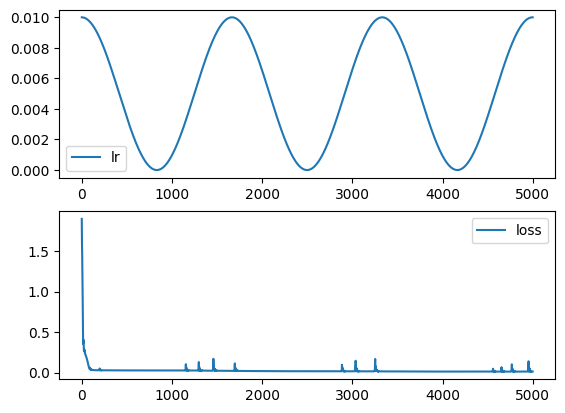

In [ ]:
lr = 0.01
num_epochs = 5000
T_scheduler = num_epochs // 6
device = "cpu"
loss_fun = torch.nn.MSELoss()

(f, _, _), params = get_model_and_derivatives(device=device)
optim = torch.optim.Adam(params, lr= lr)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optim, T_scheduler)


lrs = []
losses = []

X_train = X_train.to(device)
Y_train = Y_train.to(device)
X_test = X_test.to(device)
Y_test = Y_test.to(device)

start_time = time.time()
for epoch in range(num_epochs):
  optim.zero_grad()
  Y_pred = f(X_train)
  loss_mse = loss_fun(Y_train, Y_pred)
  loss = loss_mse
  loss.backward(retain_graph= True)
  optim.step()
  scheduler.step()
  lrs.append(scheduler.get_last_lr()[0])
  losses.append(loss.item())
  if (epoch + 1)%100 == 0:
    print(f"t: {time.time()-start_time:.2f}, Epoch {epoch+1}: MSE: {loss_mse.item():.4f}, LR: {scheduler.get_last_lr()[0]:.6f}")

plt.subplot(2, 1, 1)
plt.plot(lrs, label= 'lr')
plt.legend()
plt.subplot(2, 1, 2)
plt.plot(losses, label= 'loss')
plt.legend()
plt.show()


MSE: 0.011881832964718342


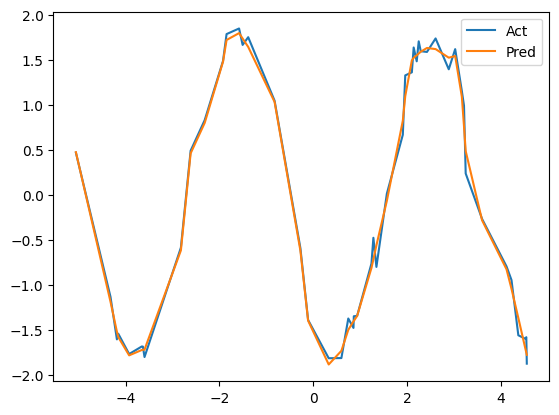

In [ ]:
test_model(f, X_train, Y_train)

MSE: 28.23651885986328


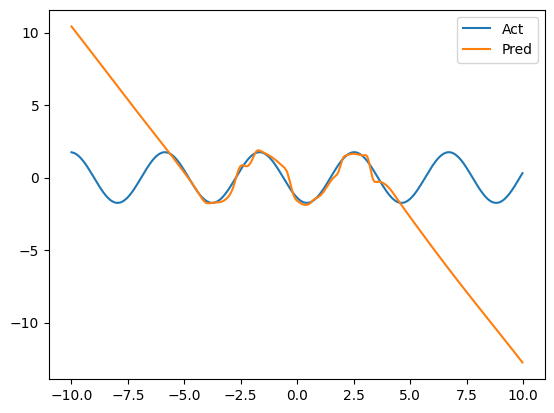

In [ ]:
test_model(f, X_test, Y_test)

We see similar behaviour as before, overfitting + poor generalization to unseen scenarios.

### PINN model: 1st try
We add a learnable parameter $\omega$.

/tmp/ipython-input-2833070047.py:39: FutureWarning: We've integrated functorch into PyTorch. As the final step of the integration, `functorch.jacrev` is deprecated as of PyTorch 2.0 and will be deleted in a future version of PyTorch >= 2.3. Please use `torch.func.jacrev` instead; see the PyTorch 2.0 release notes and/or the `torch.func` migration guide for more details https://pytorch.org/docs/main/func.migrating.html
  df_dx = vmap(jacrev(f))
/tmp/ipython-input-2833070047.py:39: FutureWarning: We've integrated functorch into PyTorch. As the final step of the integration, `functorch.vmap` is deprecated as of PyTorch 2.0 and will be deleted in a future version of PyTorch >= 2.3. Please use `torch.vmap` instead; see the PyTorch 2.0 release notes and/or the `torch.func` migration guide for more details https://pytorch.org/docs/main/func.migrating.html
  df_dx = vmap(jacrev(f))
/tmp/ipython-input-2833070047.py:40: FutureWarning: We've integrated functorch into PyTorch. As the final step of

t: 1.54, Epoch 100: MSE: 0.4996, Phys: 0.0801, LR: 0.009045, Omega: 0.33
t: 2.53, Epoch 200: MSE: 0.3415, Phys: 0.0396, LR: 0.006545, Omega: 0.50
t: 3.51, Epoch 300: MSE: 0.2504, Phys: 0.0204, LR: 0.003455, Omega: 0.72
t: 4.47, Epoch 400: MSE: 0.2132, Phys: 0.0182, LR: 0.000955, Omega: 0.80
t: 5.46, Epoch 500: MSE: 0.2074, Phys: 0.0177, LR: 0.000000, Omega: 0.81
t: 6.42, Epoch 600: MSE: 0.2016, Phys: 0.0174, LR: 0.000955, Omega: 0.83
t: 7.39, Epoch 700: MSE: 0.1694, Phys: 0.0171, LR: 0.003455, Omega: 0.91
t: 8.36, Epoch 800: MSE: 0.1450, Phys: 0.0189, LR: 0.006545, Omega: 0.95
t: 9.33, Epoch 900: MSE: 0.1301, Phys: 0.0205, LR: 0.009045, Omega: 0.96
t: 10.28, Epoch 1000: MSE: 0.1133, Phys: 0.0160, LR: 0.010000, Omega: 0.97
t: 11.57, Epoch 1100: MSE: 0.0573, Phys: 0.0102, LR: 0.009045, Omega: 1.03
t: 12.90, Epoch 1200: MSE: 0.0185, Phys: 0.0033, LR: 0.006545, Omega: 1.13
t: 13.89, Epoch 1300: MSE: 0.0133, Phys: 0.0018, LR: 0.003455, Omega: 1.16
t: 14.87, Epoch 1400: MSE: 0.0124, Phys: 0.

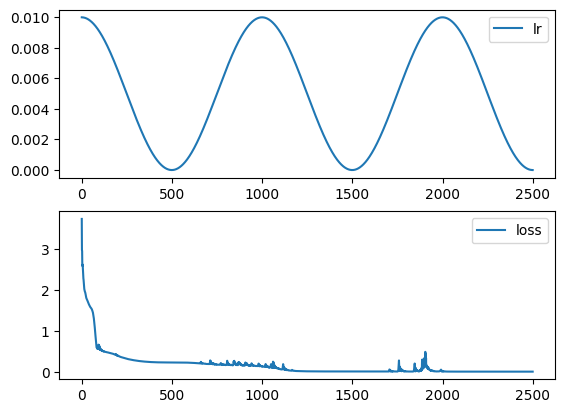

In [ ]:
# Learnable Parameter
omega_t = torch.tensor(0.75, requires_grad=True) #requires_grad is important so torch will generate gradients for this

lr = 0.01
num_epochs = 2500
T_scheduler = num_epochs // 5
coeff_phys = 1.5
device = "cpu"
loss_fun = torch.nn.MSELoss()

(f, _, d2f_dx2), params = get_model_and_derivatives(device=device)
params = [*params, omega_t] # the total set of parameters are model_parameters + omega
optim = torch.optim.Adam(params, lr= lr)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optim, T_scheduler)

lrs = []
losses_mse = []
losses_phys = []
losses = []

X_train = X_train.to(device)
Y_train = Y_train.to(device)
X_test = X_test.to(device)
Y_test = Y_test.to(device)


start_time = time.time()
for epoch in range(num_epochs):
  optim.zero_grad()
  Y_pred = f(X_train)
  d2Y_dX2_pred = d2f_dx2(X_train).reshape(-1,1)
  loss_mse = loss_fun(Y_train, Y_pred)
  # attention to the loss formula taking into account omega
  loss_phys = loss_fun(d2Y_dX2_pred, -omega_t*omega_t*Y_pred)
  loss = loss_mse + coeff_phys * loss_phys
  loss.backward(retain_graph= True)
  optim.step()
  scheduler.step()
  lrs.append(scheduler.get_last_lr()[0])
  losses_mse.append(loss_mse.item())
  losses_phys.append(loss_phys.item())
  losses.append(loss.item())
  if (epoch + 1)%100 == 0:
    print(f"t: {time.time() - start_time:.2f}, Epoch {epoch+1}: MSE: {loss_mse.item():.4f}, Phys: {loss_phys.item():.4f}, LR: {scheduler.get_last_lr()[0]:.6f}, Omega: {omega_t.item():.2f}")

plt.subplot(2, 1, 1)
plt.plot(lrs, label= 'lr')
plt.legend()
plt.subplot(2, 1, 2)
plt.plot(losses, label= 'loss')
plt.legend()
plt.show()


MSE: 0.009862377308309078


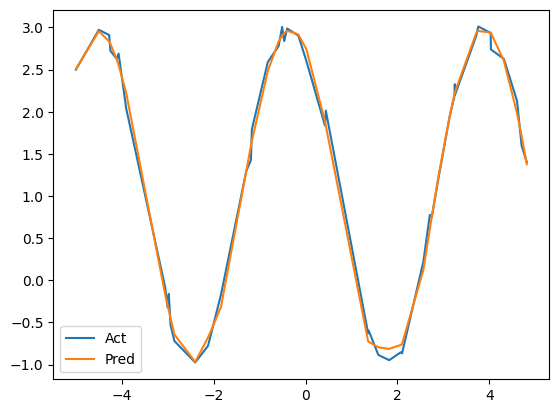

In [ ]:
test_model(f, X_train, Y_train)

MSE: 28.891189575195312


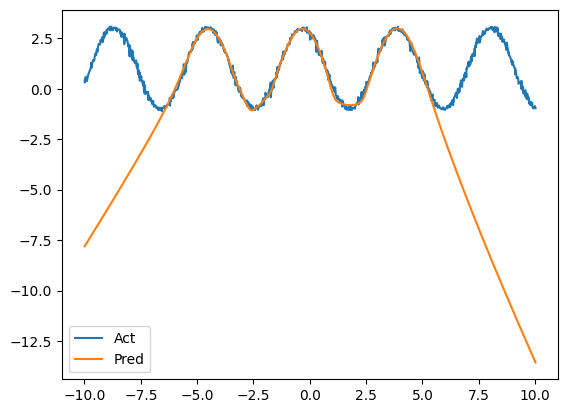

In [ ]:
test_model(f, X_test, Y_test)

## HW2:
Implement PINNs with dummy data to enhance generalization, plot graphs



/tmp/ipython-input-2059174797.py:16: FutureWarning: We've integrated functorch into PyTorch. As the final step of the integration, `functorch.jacrev` is deprecated as of PyTorch 2.0 and will be deleted in a future version of PyTorch >= 2.3. Please use `torch.func.jacrev` instead; see the PyTorch 2.0 release notes and/or the `torch.func` migration guide for more details https://pytorch.org/docs/main/func.migrating.html
  df_dx = vmap(jacrev(f))
/tmp/ipython-input-2059174797.py:16: FutureWarning: We've integrated functorch into PyTorch. As the final step of the integration, `functorch.vmap` is deprecated as of PyTorch 2.0 and will be deleted in a future version of PyTorch >= 2.3. Please use `torch.vmap` instead; see the PyTorch 2.0 release notes and/or the `torch.func` migration guide for more details https://pytorch.org/docs/main/func.migrating.html
  df_dx = vmap(jacrev(f))
/tmp/ipython-input-2059174797.py:17: FutureWarning: We've integrated functorch into PyTorch. As the final step of

t: 2.99, Epoch 100: MSE: 1.0229, Phys: 0.1095, LR: 0.009330, Omega: 0.13
t: 6.14, Epoch 200: MSE: 1.0185, Phys: 0.1107, LR: 0.007500, Omega: 0.15
t: 9.54, Epoch 300: MSE: 1.0159, Phys: 0.1112, LR: 0.005000, Omega: 0.17
t: 12.49, Epoch 400: MSE: 1.0075, Phys: 0.1124, LR: 0.002500, Omega: 0.22
t: 15.46, Epoch 500: MSE: 0.9989, Phys: 0.1133, LR: 0.000670, Omega: 0.28
t: 18.64, Epoch 600: MSE: 0.9957, Phys: 0.1136, LR: 0.000000, Omega: 0.30
t: 22.07, Epoch 700: MSE: 0.9908, Phys: 0.1139, LR: 0.000670, Omega: 0.33
t: 25.06, Epoch 800: MSE: 0.7592, Phys: 0.1542, LR: 0.002500, Omega: 0.78
t: 28.09, Epoch 900: MSE: 0.3631, Phys: 0.1582, LR: 0.005000, Omega: 1.35
t: 31.45, Epoch 1000: MSE: 0.2158, Phys: 0.1245, LR: 0.007500, Omega: 1.37
t: 34.81, Epoch 1100: MSE: 0.2084, Phys: 0.1171, LR: 0.009330, Omega: 1.36
t: 37.89, Epoch 1200: MSE: 0.1987, Phys: 0.1179, LR: 0.010000, Omega: 1.36
t: 40.93, Epoch 1300: MSE: 0.2042, Phys: 0.1143, LR: 0.009330, Omega: 1.36
t: 44.22, Epoch 1400: MSE: 0.1813, Ph

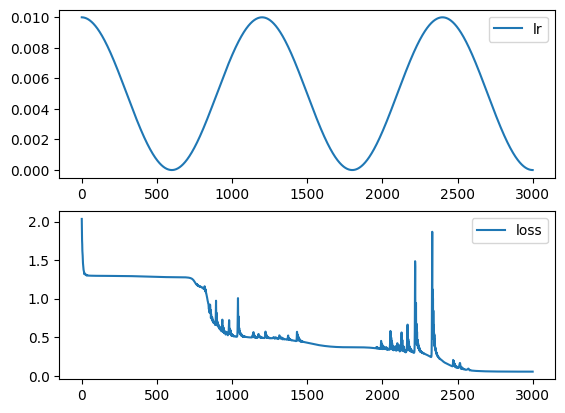

In [ ]:
# Learnable Parameter
omega_t = torch.tensor(0.01, requires_grad=True)  # requires_grad is important so torch will generate gradients for this

lr = 0.01
num_epochs = 3000
T_scheduler = num_epochs // 5
coeff_phys = 2.5
device = "cpu"
loss_fun = torch.nn.MSELoss()

(f, _, d2f_dx2), params = get_model_and_derivatives(device=device)
params = [*params, omega_t]  # the total set of parameters are model_parameters + omega
optim = torch.optim.Adam(params, lr=lr)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optim, T_scheduler)

lrs = []
losses_mse = []
losses_phys = []
losses = []

X_train = X_train.to(device)
Y_train = Y_train.to(device)
X_test = X_test.to(device)
Y_test = Y_test.to(device)

# ---- Add dummy data for physics loss ----
X_dummy = torch.arange(-10, 10, 0.01).reshape(-1, 1).to(device)

start_time = time.time()
for epoch in range(num_epochs):
    optim.zero_grad()

    # ---- Data loss (supervised) ----
    Y_pred = f(X_train)
    loss_mse = loss_fun(Y_train, Y_pred)

    # ---- Physics loss using dummy data ----
    Y_dummy_pred = f(X_dummy)
    d2Y_dummy_pred = d2f_dx2(X_dummy).reshape(-1, 1)
    loss_phys = loss_fun(d2Y_dummy_pred, -omega_t * omega_t * Y_dummy_pred)

    # ---- Total loss ----
    loss = loss_mse + coeff_phys * loss_phys

    # ---- Backpropagation ----
    loss.backward(retain_graph=True)
    optim.step()
    scheduler.step()

    lrs.append(scheduler.get_last_lr()[0])
    losses_mse.append(loss_mse.item())
    losses_phys.append(loss_phys.item())
    losses.append(loss.item())

    if (epoch + 1) % 100 == 0:
        print(f"t: {time.time() - start_time:.2f}, Epoch {epoch+1}: "
              f"MSE: {loss_mse.item():.4f}, Phys: {loss_phys.item():.4f}, "
              f"LR: {scheduler.get_last_lr()[0]:.6f}, Omega: {omega_t.item():.2f}")

plt.subplot(2, 1, 1)
plt.plot(lrs, label='lr')
plt.legend()
plt.subplot(2, 1, 2)
plt.plot(losses, label='loss')
plt.legend()
plt.show()


MSE: 0.044425953179597855


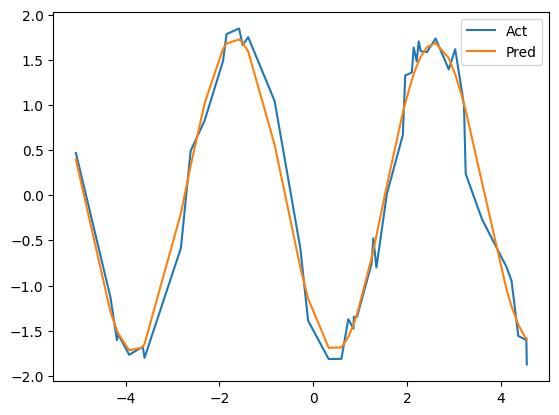

In [ ]:
test_model(f, X_train, Y_train)

MSE: 0.06962237507104874


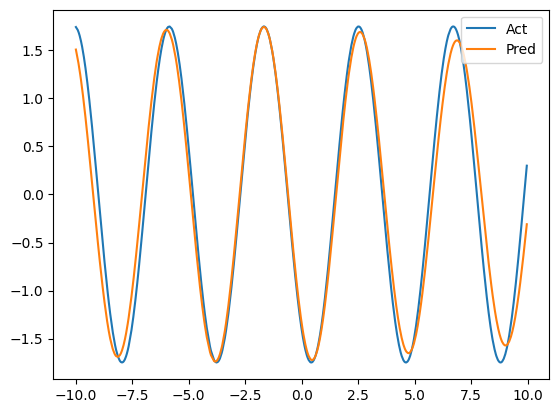

In [ ]:
test_model(f, X_test, Y_test)

## HW3:

Now we explored the case of full known DE and the case of unknown frequency. Now implement the case of unknown frequency + unknown bias, something like $y(x) = A cos(\omega x + \phi) + B$. First derive the DE operator $N$ and implement PINNs to discover and solve it.  

In [52]:
import torch
from torch.func import jacrev, hessian, vmap
import matplotlib.pyplot as plt
import time
import numpy as np

In [53]:
def get_model_and_derivatives(hidden_channels = (64, 64), activation = torch.nn.GELU, device= "cpu"):
  # construct a simple MLP
  layers = []
  inp = 1
  for h in hidden_channels:
      layers.append(torch.nn.Linear(inp, h))
      layers.append(activation())
      inp = h
  layers.append(torch.nn.Linear(inp, 1))
  model =  torch.nn.Sequential(*layers).to(device)

  # functions to compute the output and its derivatives
  # we use functions because jacrev, hessian, vmap ... requires a function and not nn.Module
  # that's why the API is called "functional"
  f = lambda x : model(x)
  df_dx = vmap(jacrev(f))
  d2f_dx2 = vmap(hessian(f))

  return (f, df_dx, d2f_dx2), model.parameters()

In [54]:
def test_model(f, X, Y):
  # simple check for f(X) vs Y,
  print(f"MSE: {torch.nn.functional.mse_loss(f(X), Y)}")
  sorted_indices = torch.argsort(X.flatten())
  X = X[sorted_indices].reshape(-1,1)
  Y = Y[sorted_indices].reshape(-1,1)
  plt.plot(X.detach().cpu(), Y.detach().cpu(), label= 'Act')
  plt.plot(X.detach().cpu(), f(X).detach().cpu(), label= 'Pred')
  plt.legend()
  plt.plot()

In [94]:

# Generate synthetic data with cosine + bias

def generate_data(interval=(-torch.pi, torch.pi), num_samples=1000,
                  A=1.0, phi=0.0, omega=1.5, B=0.5):
    """
    Generate synthetic data for y(x) = A*cos(omega*x + phi) + B.
    Also verifies that the DE: y'' + omega^2*(y - B) ≈ 0 holds.
    """
    X = (interval[1] - interval[0]) * torch.rand((num_samples, 1), requires_grad=True) + interval[0]

    # Define the true function
    f = lambda x: A * torch.cos(omega * x + phi) + B
    Y = f(X)

    print(f"Generated dataset with {num_samples} samples, "
          f"x in [{X.min().item():.2f}, {X.max().item():.2f}], "
          f"y(x) = {A:.2f} cos({omega:.2f}x {phi:+.2f}) + {B:.2f}")

    # --- Check if the differential equation holds ---
    # DE: y'' + omega^2 * (y - B) = 0

    # First derivative (B disappears)
    df_dx = vmap(jacrev(lambda x: A * torch.cos(omega * x + phi)))
    dY_dX = df_dx(X).reshape(Y.shape)

    # Second derivative
    d2f_dx2 = vmap(hessian(lambda x: A * torch.cos(omega * x + phi)))
    d2Y_dX2 = d2f_dx2(X).reshape(Y.shape)

    # Compute DE residual
    N = d2Y_dX2 + omega**2 * (Y - B)
    mse_residual = torch.mean(torch.square(N)).item()

    if torch.allclose(torch.mean(torch.square(N)), torch.tensor(0.), atol=1e-6):
        print("Differential equation holds (checked on true function).")
    else:
        print(f"Warning: DE residual not exactly zero (mean squared residual = {mse_residual:.6e})")

    return (X, Y)



# Generate training and test sets

def generate_train_test(interval_train, num_samples_train,
                        interval_test, num_samples_test, omega, B):
    """
    Generates train and test datasets with same A, phi, B but different X ranges.
    """
    A = 3 * torch.rand(()) + 1                # amplitude in [1, 4]
    phi = 2 * torch.pi * torch.rand(()) - torch.pi  # phase in [-pi, pi]
    #B = 2 * torch.rand(()) - 1                # bias in [-1, 1]
    print(f"True parameters: A={A.item():.3f}, phi={phi.item():.3f}, omega={omega:.3f}, B={B:.3f}")

    train_data = generate_data(interval_train, num_samples_train, A, phi, omega, B)
    test_data = generate_data(interval_test, num_samples_test, A, phi, omega, B)
    return train_data, test_data



# Create noisy training and test datasets

(X_train, Y_train), (X_test, Y_test) = generate_train_test([-5, 5], 50, [-10, 10], 1000, omega=1.5, B=0.5)

# Add small Gaussian noise to simulate measurement error
X_train += 0.1 * torch.randn_like(X_train)
Y_train += 0.1 * torch.randn_like(Y_train)

True parameters: A=3.317, phi=-2.345, omega=1.500, B=0.500
Generated dataset with 50 samples, x in [-4.86, 4.34], y(x) = 3.32 cos(1.50x -2.35) + 0.50
Differential equation holds (checked on true function).
Generated dataset with 1000 samples, x in [-9.99, 9.99], y(x) = 3.32 cos(1.50x -2.35) + 0.50
Differential equation holds (checked on true function).


t: 0.26, Epoch 100: MSE: 0.2722, LR: 0.009649
t: 0.50, Epoch 200: MSE: 0.1447, LR: 0.008644
t: 0.75, Epoch 300: MSE: 0.0748, LR: 0.007127
t: 1.02, Epoch 400: MSE: 0.0625, LR: 0.005311
t: 1.24, Epoch 500: MSE: 0.0595, LR: 0.003451
t: 1.43, Epoch 600: MSE: 0.0584, LR: 0.001809
t: 1.61, Epoch 700: MSE: 0.0579, LR: 0.000616
t: 1.79, Epoch 800: MSE: 0.0578, LR: 0.000039
t: 1.97, Epoch 900: MSE: 0.0577, LR: 0.000159
t: 2.15, Epoch 1000: MSE: 0.0574, LR: 0.000959
t: 2.35, Epoch 1100: MSE: 0.0559, LR: 0.002328
t: 2.52, Epoch 1200: MSE: 0.0510, LR: 0.004072
t: 2.69, Epoch 1300: MSE: 0.0448, LR: 0.005947
t: 2.87, Epoch 1400: MSE: 0.0386, LR: 0.007688
t: 3.12, Epoch 1500: MSE: 0.0381, LR: 0.009052
t: 3.38, Epoch 1600: MSE: 0.0369, LR: 0.009846
t: 3.64, Epoch 1700: MSE: 0.0408, LR: 0.009959
t: 3.91, Epoch 1800: MSE: 0.0361, LR: 0.009375
t: 4.17, Epoch 1900: MSE: 0.0354, LR: 0.008176
t: 4.42, Epoch 2000: MSE: 0.0350, LR: 0.006531
t: 4.69, Epoch 2100: MSE: 0.0346, LR: 0.004670
t: 4.99, Epoch 2200: M

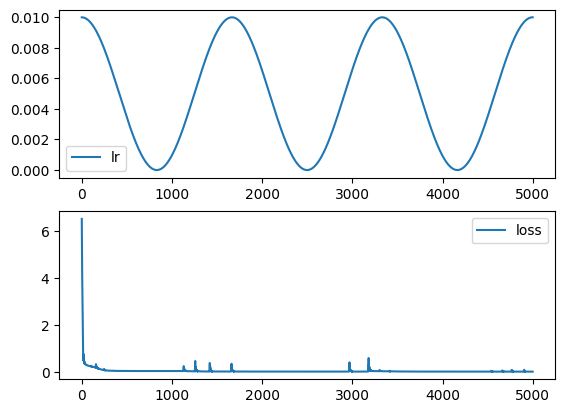

In [95]:
lr = 0.01
num_epochs = 5000
T_scheduler = num_epochs // 6
device = "cpu"
loss_fun = torch.nn.MSELoss()

(f, _, _), params = get_model_and_derivatives(device=device)
optim = torch.optim.Adam(params, lr= lr)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optim, T_scheduler)


lrs = []
losses = []

X_train = X_train.to(device)
Y_train = Y_train.to(device)
X_test = X_test.to(device)
Y_test = Y_test.to(device)

start_time = time.time()
for epoch in range(num_epochs):
  optim.zero_grad()
  Y_pred = f(X_train)
  loss_mse = loss_fun(Y_train, Y_pred)
  loss = loss_mse
  loss.backward(retain_graph= True)
  optim.step()
  scheduler.step()
  lrs.append(scheduler.get_last_lr()[0])
  losses.append(loss.item())
  if (epoch + 1)%100 == 0:
    print(f"t: {time.time()-start_time:.2f}, Epoch {epoch+1}: MSE: {loss_mse.item():.4f}, LR: {scheduler.get_last_lr()[0]:.6f}")

plt.subplot(2, 1, 1)
plt.plot(lrs, label= 'lr')
plt.legend()
plt.subplot(2, 1, 2)
plt.plot(losses, label= 'loss')
plt.legend()
plt.show()


MSE: 0.03214902803301811


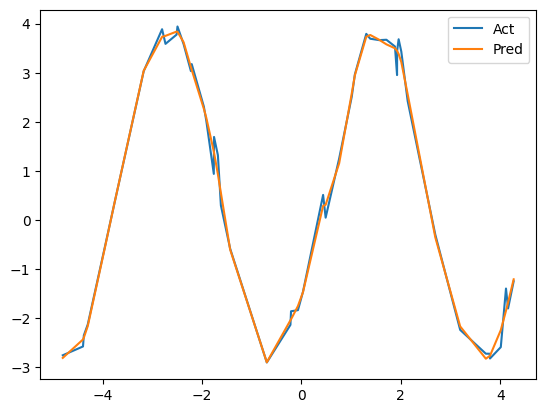

In [96]:
test_model(f, X_train, Y_train)

MSE: 17.951526641845703


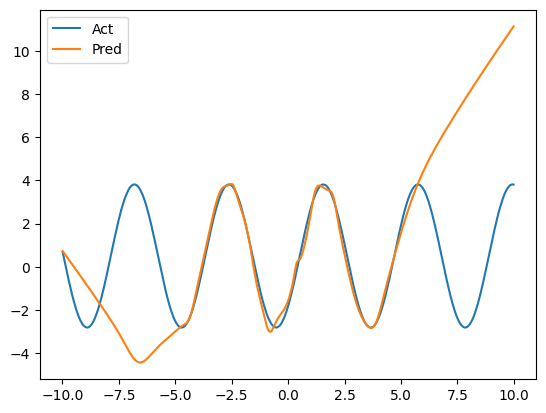

In [97]:
test_model(f, X_test, Y_test)

t: 5.53, Epoch 100: MSE: 2.2595, Phys: 0.6426, LR: 0.009619, Omega: 0.18, Bias: -1.1118
t: 10.52, Epoch 200: MSE: 2.2333, Phys: 0.6261, LR: 0.008536, Omega: 0.24, Bias: -2.3742
t: 14.98, Epoch 300: MSE: 2.1912, Phys: 0.6149, LR: 0.006913, Omega: 0.28, Bias: -3.3803
t: 20.58, Epoch 400: MSE: 2.1437, Phys: 0.6082, LR: 0.005000, Omega: 0.31, Bias: -3.9600
t: 25.58, Epoch 500: MSE: 2.0881, Phys: 0.6156, LR: 0.003087, Omega: 0.33, Bias: -4.1971
t: 30.34, Epoch 600: MSE: 2.0598, Phys: 0.6184, LR: 0.001464, Omega: 0.35, Bias: -4.2363
t: 34.95, Epoch 700: MSE: 2.0490, Phys: 0.6189, LR: 0.000381, Omega: 0.35, Bias: -4.2298
t: 39.15, Epoch 800: MSE: 2.0474, Phys: 0.6190, LR: 0.000000, Omega: 0.36, Bias: -4.2275
t: 44.23, Epoch 900: MSE: 2.0457, Phys: 0.6192, LR: 0.000381, Omega: 0.36, Bias: -4.2247
t: 48.45, Epoch 1000: MSE: 2.0339, Phys: 0.6212, LR: 0.001464, Omega: 0.36, Bias: -4.1951
t: 52.67, Epoch 1100: MSE: 2.0177, Phys: 0.6268, LR: 0.003087, Omega: 0.38, Bias: -4.0521
t: 57.68, Epoch 1200

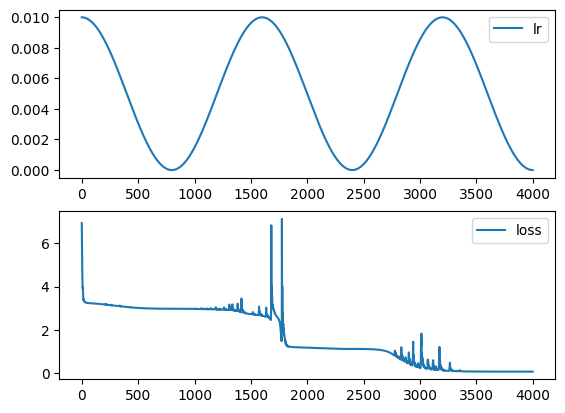

In [109]:
# === PINN: learnable omega and bias B ===
omega_t = torch.tensor(0.01, requires_grad=True)   # start small but >0
B_t = torch.tensor(0.01, requires_grad=True)       # initial bias guess

lr = 0.01
num_epochs = 4000
T_scheduler = num_epochs // 5
coeff_phys = 1.5   # physics loss weight (tune if needed)
device = "cpu"
loss_fun = torch.nn.MSELoss()

# get model + second derivative function
(f, _, d2f_dx2), params = get_model_and_derivatives(device=device)
params = [*params, omega_t, B_t]  # include both physical scalars

optim = torch.optim.Adam(params, lr=lr)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optim, T_scheduler)

# dense collocation (dummy) points for physics
X_dummy = torch.arange(-10, 10, 0.01).reshape(-1, 1).to(device)

lrs = []
losses_mse = []
losses_phys = []
losses = []

X_train = X_train.to(device)
Y_train = Y_train.to(device)
X_test = X_test.to(device)
Y_test = Y_test.to(device)

start_time = time.time()
for epoch in range(num_epochs):
    optim.zero_grad()

    # data loss (supervised)
    Y_pred = f(X_train)
    loss_mse = loss_fun(Y_train, Y_pred)

    # physics loss (on dummy points)
    Y_dummy_pred = f(X_dummy)
    d2Y_dummy_pred = d2f_dx2(X_dummy).reshape(-1, 1)

    # physics residual: d2y + omega^2 * (y - B) = 0
    phys_residual = d2Y_dummy_pred + (omega_t * omega_t) * (Y_dummy_pred - B_t)
    loss_phys = loss_fun(phys_residual, torch.zeros_like(phys_residual))

    # total loss
    loss = loss_mse + coeff_phys * loss_phys

    # ---- Backpropagation ----
    loss.backward(retain_graph=True)
    optim.step()
    scheduler.step()

    lrs.append(scheduler.get_last_lr()[0])
    losses_mse.append(loss_mse.item())
    losses_phys.append(loss_phys.item())
    losses.append(loss.item())

    if (epoch + 1) % 100 == 0:
        print(f"t: {time.time() - start_time:.2f}, Epoch {epoch+1}: "
              f"MSE: {loss_mse.item():.4f}, Phys: {loss_phys.item():.4f}, "
              f"LR: {scheduler.get_last_lr()[0]:.6f}, Omega: {omega_t.item():.2f}, Bias: {B_t.item():.4f}")

plt.subplot(2, 1, 1)
plt.plot(lrs, label='lr')
plt.legend()
plt.subplot(2, 1, 2)
plt.plot(losses, label='loss')
plt.legend()
plt.show()

MSE: 0.06358738243579865


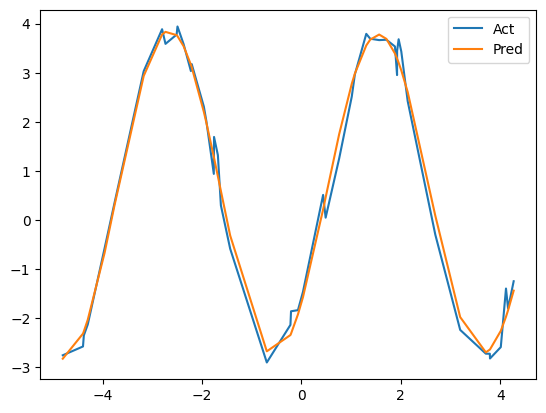

In [110]:
test_model(f, X_train, Y_train)

MSE: 0.03049086406826973


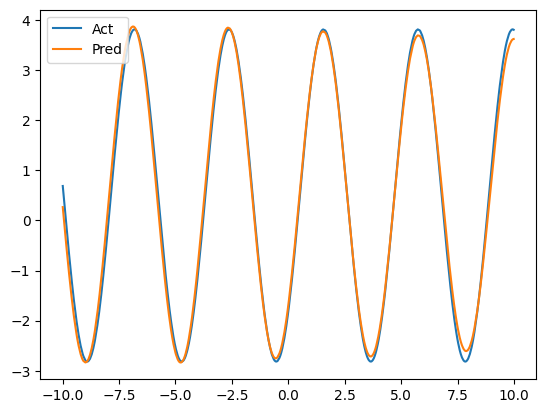

In [111]:
test_model(f, X_test, Y_test)

## HW4:
Q: Can we use ReLU activation function in the NNs of the previous tasks? why?


No — ReLU is not an appropriate activation function for modeling harmonic oscillator dynamics.


*   Harmonic oscillator dynamics are smooth and continuous.

*   They involve sinusoidal motion, meaning both the function and its derivatives change smoothly over time.

*   ReLU (Rectified Linear Unit), on the other hand, is piecewise linear — it has sharp corners and its second derivative is zero almost everywhere.

*   Because of this, ReLU cannot effectively represent the curved, oscillatory behavior that harmonic systems exhibit.

*   In contrast, smooth nonlinear activations like Tanh or Sin are much better suited, as they can capture both the curvature and periodicity required to model such systems accurately.














## HW5:
 Following the same principles use a PINNs to learn the dynamics of simplified 2D multirotor

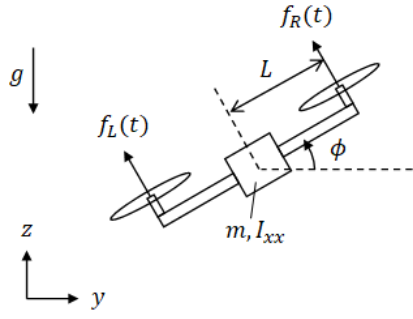

The state is $x = [y, z, \phi, v_y, v_z, \omega]$, the input is the thrust of left and right rotors $u = [f_L, f_R]$
We have the following parameters of the model (could be inaccurate)
$m = 0.35, I_{xx} = 0.005, L = 0.1, g= 9.81$

1. Derive the analytical model, define $\dot{x} = f(x, u)$

2. Create a python function to get the predicted state dynamics $\dot{x}$ based on the analytical model

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.autograd.functional import jacobian
from torch.autograd import grad
import pandas as pd
import numpy as np
import time
import math
import matplotlib.pyplot as plt

In [ ]:
def f_anlt(x, u):
    """
    x: (B,6) tensor [y, z, phi, vy, vz, omega]
    u: (B,2) tensor [fL, fR]
    returns x_dot (B,6) in the same order:
      [y_dot, z_dot, phi_dot, vy_dot, vz_dot, omega_dot]
    """
    m = 0.35
    I_xx = 0.005
    L = 0.1
    g = 9.81

    y = x[:, 0]
    z = x[:, 1]
    phi = x[:, 2]
    vy = x[:, 3]
    vz = x[:, 4]
    omega = x[:, 5]

    fL = u[:, 0]
    fR = u[:, 1]
    fsum = fL + fR
    fdiff = fR - fL

    y_dot = vy
    z_dot = vz
    phi_dot = omega
    vy_dot = - (fsum / m) * torch.sin(phi)
    vz_dot = (fsum / m) * torch.cos(phi) - g
    omega_dot = (L * fdiff) / I_xx

    return torch.stack([y_dot, z_dot, phi_dot, vy_dot, vz_dot, omega_dot], dim=1)

In [ ]:
# Download traing and test sets
import gdown
gdown.download('https://drive.google.com/file/d/1mdCwjWupljOQH4ySLUxuTytD1Hsrzfho/view?usp=sharing', fuzzy= True)
gdown.download('https://drive.google.com/file/d/1LngllwyXvPtWD7vB-cceaFibf0UDY7N4/view?usp=sharing', fuzzy= True)

import pandas as pd

df = pd.read_csv('train.csv')

x = df[['y', 'z', 'phi', 'vy', 'vz', 'omega']].values
u = df[['ul', 'ur']].values

x_next = df[['y_next', 'z_next', 'phi_next', 'vy_next', 'vz_next', 'omega_next']].values
u_next = df[['ul_next', 'ur_next']].values

xu = np.concatenate([x, u], axis=1)
dxu = np.concatenate([x_next - x, u_next - u], axis=1)

X_train = torch.tensor(xu, dtype=torch.float32)
dX_train = torch.tensor(dxu, dtype=torch.float32)
Y_train = torch.tensor(x_next, dtype=torch.float32)

# incuce noise
X_train += 0.1 * torch.randn_like(X_train)
Y_train += 0.1 * torch.randn_like(Y_train)

# decrease number of samples
frac_samples = 10
X_train = X_train[::frac_samples]
dX_train = dX_train[::frac_samples]
Y_train = Y_train[::frac_samples]

df_test = pd.read_csv('test.csv')

x = df_test[['y', 'z', 'phi', 'vy', 'vz', 'omega']].values
u = df_test[['ul', 'ur']].values
x_next = df_test[['y_next', 'z_next', 'phi_next', 'vy_next', 'vz_next', 'omega_next']].values
xu = np.concatenate([x, u], axis=1)

X_test = torch.tensor(xu, dtype=torch.float32)
Y_test = torch.tensor(x_next, dtype=torch.float32)

X_train.shape, dX_train.shape, Y_train.shape, X_test.shape, Y_test.shape

Downloading...
From: https://drive.google.com/uc?id=1mdCwjWupljOQH4ySLUxuTytD1Hsrzfho
To: /content/train.csv
100%|██████████| 17.3M/17.3M [00:00<00:00, 274MB/s]
Downloading...
From: https://drive.google.com/uc?id=1LngllwyXvPtWD7vB-cceaFibf0UDY7N4
To: /content/test.csv
100%|██████████| 334k/334k [00:00<00:00, 76.7MB/s]


(torch.Size([5000, 8]),
 torch.Size([5000, 8]),
 torch.Size([5000, 6]),
 torch.Size([999, 8]),
 torch.Size([999, 6]))

3. Create a deep learning model that predict the next state $x_{k+1} = f_{NN}(x_k, u_k)$

In [ ]:
# ✅ 3. Neural Network Model
class Model(nn.Module):
    def __init__(self, hidden_sizes=(128, 128, 128, 128)):
        super().__init__()
        layers = []
        input_size = 8  # states (6) + controls (2)
        for h in hidden_sizes:
            layers.append(nn.Linear(input_size, h))
            layers.append(nn.Tanh())
            input_size = h
        layers.append(nn.Linear(input_size, 6))  # output dx/dt
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

4. Create the learning pipeline with the loss:

$\mathcal{L}_{d} = \frac{1}{N-1}\sum_{k=2}^{N}{\|f_{NN}(x_{k-1},
				            u_{k-1}; \theta) - x_{k}\|^2}$

$\mathcal{L}_{ph} = \frac{1}{N-1}\sum_{k=2}^{N}{\| \frac{\partial
					            f_{NN}}{\partial x}(x_k, u_k; \theta) \Delta x_k + \frac{\partial
					            f_{NN}}{\partial u}(x_k, u_k; \theta) \Delta u_k - f_{anlt}(x_k, u_k) \Delta
				            t\|^2}$

 $\mathcal{L} = \mathcal{L}_{d} + \gamma \mathcal{L}_{ph}$

Train the model on the train dataset


Epoch 200: Ld=7.73795, Lph=0.00000, Total=7.73795
Epoch 400: Ld=2.66979, Lph=0.65431, Total=2.76794
Epoch 600: Ld=1.27567, Lph=0.49474, Total=1.34989
Epoch 800: Ld=0.71020, Lph=0.21842, Total=0.74296
Epoch 1000: Ld=0.52166, Lph=0.62845, Total=0.61593
Epoch 1200: Ld=0.40078, Lph=0.83173, Total=0.52554
Epoch 1400: Ld=0.33919, Lph=0.75284, Total=0.45211
Epoch 1600: Ld=0.29091, Lph=1.03988, Total=0.44689
Epoch 1800: Ld=0.26103, Lph=0.70294, Total=0.36647
Epoch 2000: Ld=0.23882, Lph=0.47224, Total=0.30966
Epoch 2200: Ld=0.20895, Lph=0.64225, Total=0.30528
Epoch 2400: Ld=0.18444, Lph=0.68535, Total=0.28724
Epoch 2600: Ld=0.16219, Lph=0.69734, Total=0.26679
Epoch 2800: Ld=0.14465, Lph=0.66341, Total=0.24416
Epoch 3000: Ld=0.14174, Lph=0.43045, Total=0.20630
Epoch 3200: Ld=0.12907, Lph=0.85402, Total=0.25717
Epoch 3400: Ld=0.12802, Lph=0.78542, Total=0.24584
Epoch 3600: Ld=0.10602, Lph=0.63035, Total=0.20057
Epoch 3800: Ld=0.10061, Lph=0.48235, Total=0.17296
Epoch 4000: Ld=0.09261, Lph=0.82157

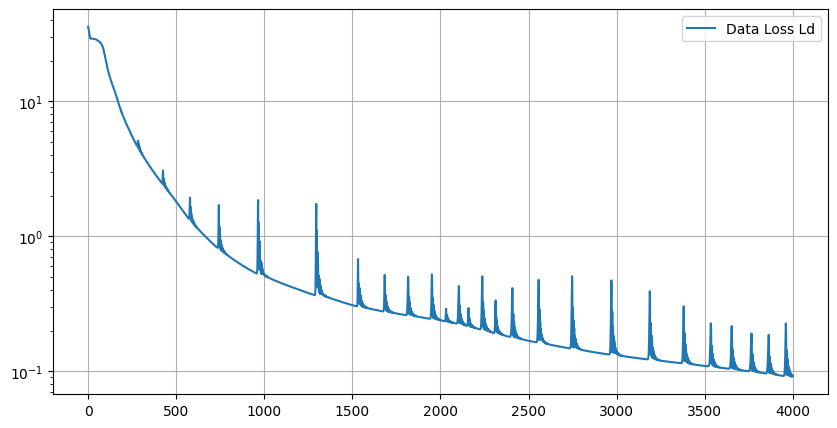

In [ ]:
# 1. Load Dataset
df = pd.read_csv('train.csv')
x = df[['y', 'z', 'phi', 'vy', 'vz', 'omega']].values
u = df[['ul', 'ur']].values
x_next = df[['y_next', 'z_next', 'phi_next', 'vy_next', 'vz_next', 'omega_next']].values

xu = np.concatenate([x, u], axis=1)
dx = (x_next - x) / 0.02    # derivative (dx/dt)

X_train = torch.tensor(xu, dtype=torch.float32)
dX_train = torch.tensor(dx, dtype=torch.float32)

# Test Dataset
df_test = pd.read_csv('test.csv')
x_t = df_test[['y', 'z', 'phi', 'vy', 'vz', 'omega']].values
u_t = df_test[['ul', 'ur']].values
x_next_t = df_test[['y_next', 'z_next', 'phi_next', 'vy_next', 'vz_next', 'omega_next']].values

xu_test = np.concatenate([x_t, u_t], axis=1)
dx_test = (x_next_t - x_t) / 0.02

X_test = torch.tensor(xu_test, dtype=torch.float32)
dX_test = torch.tensor(dx_test, dtype=torch.float32)

# 2. Device Setup (Use GPU if available)
device = "cuda" if torch.cuda.is_available() else "cpu"
X_train, dX_train = X_train.to(device), dX_train.to(device)
X_test, dX_test = X_test.to(device), dX_test.to(device)

# 4. Pretend Analytical Function (Replace with real one)
def f_analytical(xu):
    return torch.zeros_like(xu[:, :6])  # Placeholder

# 5. Physics Loss Function (Optimized)
def physics_loss(model, Xfull, Δt=0.03, phys_B=32):
    idx = torch.randint(0, Xfull.shape[0]-1, (phys_B,))
    Xp = Xfull[idx].clone().detach().requires_grad_(True)

    fx = model(Xp)

    Jx_list, Ju_list = [], []
    for i in range(6):  # Loop through output dims
        g = grad(fx[:, i].sum(), Xp, retain_graph=True, create_graph=False)[0]  # (B,8)
        Jx_list.append(g[:, :6])  # (B,6)
        Ju_list.append(g[:, 6:])  # (B,2)

    Jx = torch.stack(Jx_list, dim=2)  # (B,6,6)
    Ju = torch.stack(Ju_list, dim=2)  # (B,2,6) → transpose later

    # Compute Δx and Δu from data
    xk = Xp[:, :6]               # (B,6)
    uk = Xp[:, 6:]               # (B,2)
    xk1 = Xfull[idx + 1, :6]     # next-step
    dx = (xk1 - xk)              # (B,6)
    du = torch.zeros_like(uk)    # if controls are constant

    # Rearrange for matmul: (B,6,1) and (B,2,1)
    dx = dx.unsqueeze(-1)        # (B,6,1)
    du = du.unsqueeze(-1)        # (B,2,1)

    # Compute: Jx*dx + Ju*du
    term = torch.matmul(Jx, dx) + torch.matmul(Ju.transpose(1,2), du)  # (B,6,1)

    # Analytical model
    fan = f_analytical(Xp) * Δt
    fan = fan.unsqueeze(-1)      # (B,6,1)

    # Residual
    res = term - fan
    Lph = torch.mean(res ** 2)

    return Lph


# 6. Training Setup
model = Model().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
loss_fun = nn.MSELoss()

num_epochs = 4000
T_scheduler = num_epochs/5
warmup_epochs = 300  # only data loss first
γ = 0.15

losses = []
phys_losses = []

# 7. Training Loop
for epoch in range(num_epochs):
    optimizer.zero_grad()
    pred = model(X_train)
    Ld = loss_fun(pred, dX_train)

    if epoch > warmup_epochs:
        Lph = physics_loss(model, X_train)
    else:
        Lph = 0.0

    loss = Ld + γ * Lph
    loss.backward()
    optimizer.step()

    losses.append(Ld.item())
    phys_losses.append(Lph if isinstance(Lph, float) else Lph.item())

    if (epoch + 1) % 200 == 0:
        print(f"Epoch {epoch+1}: Ld={Ld:.5f}, Lph={Lph:.5f}, Total={loss:.5f}")

print("Training Completed!")

# Plot Losses
plt.figure(figsize=(10,5))
plt.plot(losses, label="Data Loss Ld")
plt.yscale('log')
plt.legend()
plt.grid()
plt.show()


=== TEST EVALUATION ===

Data scale check:
dX_test mean: -0.757821
dX_test std: 31.890079
Interpretation: dX_test represents derivatives (dx/dt), using dX_pred = x_dot_pred
dX_pred_test mean: -0.656168
dX_pred_test std: 23.622818

Test Data Loss (L_d): 83.962852
Test Physics Loss (L_ph): 558.375061
Test Total Loss: 642.337891

State-wise Mean Absolute Errors:
  y: 0.902814
  z: 1.940634
  phi: 0.120070
  vy: 9.698665
  vz: 11.180239
  omega: 3.855788

=== PREDICTION VISUALIZATION ===


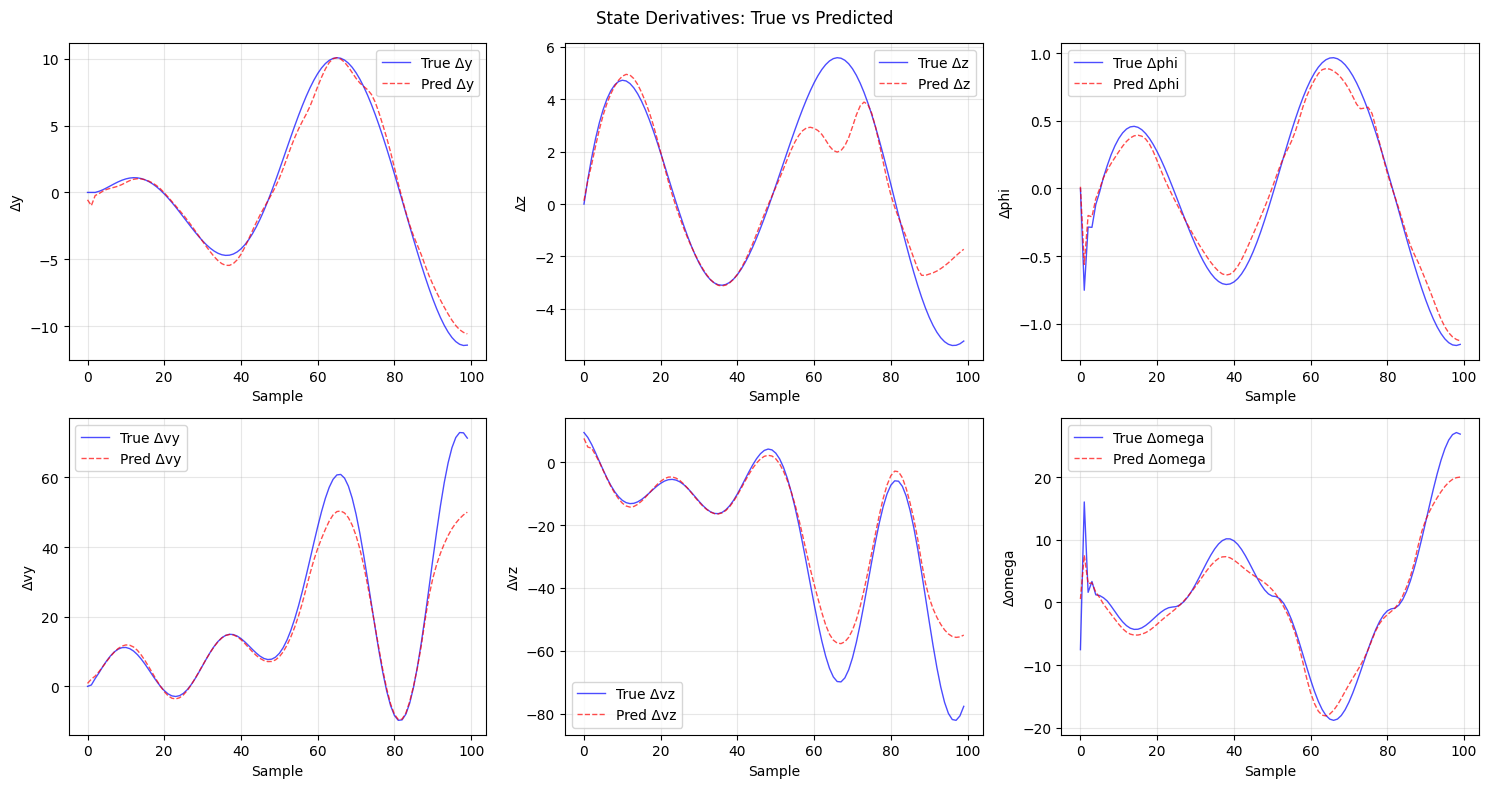

In [ ]:
# TEST EVALUATION
print("\n=== TEST EVALUATION ===")
model.eval()
dt = 0.01  # same as used for derivative computation

with torch.no_grad():
    # Split test input
    x_k_test = X_test[:, :6]  # state variables
    u_k_test = X_test[:, 6:]  # control inputs

    # Predictions
    x_dot_pred = model(X_test)

    # --- Data scale check ---
    print(f"\nData scale check:")
    print(f"dX_test mean: {dX_test.mean().item():.6f}")
    print(f"dX_test std: {dX_test.std().item():.6f}")

    # Decide whether dX_test is Δx or dx/dt
    if abs(dX_test.mean().item()) < 0.1:
        dX_pred_test = x_dot_pred * dt
        print("Interpretation: dX_test represents state changes (Δx), using dX_pred = x_dot_pred * dt")
    else:
        dX_pred_test = x_dot_pred
        print("Interpretation: dX_test represents derivatives (dx/dt), using dX_pred = x_dot_pred")

    print(f"dX_pred_test mean: {dX_pred_test.mean().item():.6f}")
    print(f"dX_pred_test std: {dX_pred_test.std().item():.6f}")

    # --- Test losses ---
    test_loss_d = loss_fun(dX_pred_test, dX_test)
    x_dot_anlyt_test = f_analytical(X_test)  # same dummy analytical model
    test_loss_ph = loss_fun(x_dot_pred, x_dot_anlyt_test)
    coeff_phys = 1.0
    test_loss_total = test_loss_d + coeff_phys * test_loss_ph

    print(f"\nTest Data Loss (L_d): {test_loss_d.item():.6f}")
    print(f"Test Physics Loss (L_ph): {test_loss_ph.item():.6f}")
    print(f"Test Total Loss: {test_loss_total.item():.6f}")

    # --- State-wise mean absolute error ---
    state_errors = torch.abs(dX_pred_test - dX_test).mean(dim=0)
    state_names = ['y', 'z', 'phi', 'vy', 'vz', 'omega']
    print("\nState-wise Mean Absolute Errors:")
    for i, name in enumerate(state_names):
        print(f"  {name}: {state_errors[i].item():.6f}")

# VISUALIZATION: Predicted vs True (for first 100 samples)
print("\n=== PREDICTION VISUALIZATION ===")
with torch.no_grad():
    n_vis = min(100, X_test.shape[0])
    x_dot_vis = model(X_test[:n_vis])

    if abs(dX_test.mean().item()) < 0.1:
        dx_pred_vis = x_dot_vis * dt
    else:
        dx_pred_vis = x_dot_vis

    dx_true_vis = dX_test[:n_vis].cpu().numpy()
    dx_pred_vis = dx_pred_vis.cpu().numpy()

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    state_names = ['y', 'z', 'phi', 'vy', 'vz', 'omega']

    for i, ax in enumerate(axes.flat):
        ax.plot(dx_true_vis[:, i], 'b-', alpha=0.7, label='True Δ' + state_names[i], linewidth=1)
        ax.plot(dx_pred_vis[:, i], 'r--', alpha=0.7, label='Pred Δ' + state_names[i], linewidth=1)
        ax.set_xlabel('Sample')
        ax.set_ylabel(f'Δ{state_names[i]}')
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.suptitle('State Derivatives: True vs Predicted')
    plt.tight_layout()
    plt.show()

5. comapre between the analytical model and the trained model on the test dataset

In [108]:
model.eval()
with torch.no_grad():
    # Split test input
    x_k_test = X_test[:, :6]  # State variables (first 6 columns)
    u_k_test = X_test[:, 6:]  # Control inputs

    # Prediction with PINN
    x_dot_nn_test = model(X_test)
    dt = 0.01
    dX_pred_nn = x_dot_nn_test  # Model predicts derivatives directly

    # Prediction using analytical model
    x_dot_anlyt_test = f_anlyt(x_k_test, u_k_test)
    dX_pred_anlyt = x_dot_anlyt_test

    # MSE Calculation
    mse_nn = loss_fun(dX_pred_nn, dX_test)
    mse_anlyt = loss_fun(dX_pred_anlyt, dX_test)

    print(f"MSE (PINN): {mse_nn.item():.8f}")
    print(f"MSE (Analytical Model): {mse_anlyt.item():.8f}")

    # Performance comparison for each component individually
    state_names = ['y', 'z', 'phi', 'vy', 'vz', 'omega']
    print("\n--- MSE by state components ---")
    for i in range(6):
        mse_nn_comp = loss_fun(dX_pred_nn[:, i], dX_test[:, i])
        mse_anlyt_comp = loss_fun(dX_pred_anlyt[:, i], dX_test[:, i])
        print(f"d{state_names[i]}/dt | PINN: {mse_nn_comp.item():.8f} | Analytical: {mse_anlyt_comp.item():.8f}")

MSE (PINN): 83.96285248
MSE (Analytical Model): 1010.01367188

--- MSE by state components ---
dy/dt | PINN: 6.44358969 | Analytical: 52.64723969
dz/dt | PINN: 7.26507616 | Analytical: 9.47302437
dphi/dt | PINN: 0.11234190 | Analytical: 0.58547425
dvy/dt | PINN: 203.84541321 | Analytical: 2494.80737305
dvz/dt | PINN: 255.89877319 | Analytical: 3146.06274414
domega/dt | PINN: 30.21189690 | Analytical: 356.50595093


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
from torch.autograd import grad
from torch.autograd.functional import jacobian

In [ ]:
def f_anlyt(x, u):
  m = 0.35
  I_xx = 0.005
  L = 0.1
  g = 9.81

  #states
  y, z, phi, vy, vz, omega = x[:, 0], x[:, 1], x[:, 2], x[:, 3], x[:, 4], x[:, 5]

  #controls
  fL, fR = u[:, 0], u[:, 1]

  F_total = fL + fR #(in body z-direction)

  ydot = vy
  zdot = vz
  phidot = omega
  vydot = -(F_total / m) * torch.sin(phi)
  vzdot = (F_total / m) * torch.cos(phi) - g
  omegadot = L * (fR - fL) / I_xx

  x_dot = torch.stack([ydot, zdot, phidot, vydot, vzdot, omegadot], dim=1)

  return x_dot

In [ ]:
# Download traing and test sets
import gdown
gdown.download('https://drive.google.com/file/d/1mdCwjWupljOQH4ySLUxuTytD1Hsrzfho/view?usp=sharing', fuzzy= True)
gdown.download('https://drive.google.com/file/d/1LngllwyXvPtWD7vB-cceaFibf0UDY7N4/view?usp=sharing', fuzzy= True)

import pandas as pd

df = pd.read_csv('train.csv')

x = df[['y', 'z', 'phi', 'vy', 'vz', 'omega']].values
u = df[['ul', 'ur']].values

x_next = df[['y_next', 'z_next', 'phi_next', 'vy_next', 'vz_next', 'omega_next']].values
u_next = df[['ul_next', 'ur_next']].values

xu = np.concatenate([x, u], axis=1)
dxu = np.concatenate([x_next - x, u_next - u], axis=1)

X_train = torch.tensor(xu, dtype=torch.float32)
dX_train = torch.tensor(dxu, dtype=torch.float32)
Y_train = torch.tensor(x_next, dtype=torch.float32)

# incuce noise
X_train += 0.1 * torch.randn_like(X_train)
Y_train += 0.1 * torch.randn_like(Y_train)

# decrease number of samples
frac_samples = 10
X_train = X_train[::frac_samples]
dX_train = dX_train[::frac_samples]
Y_train = Y_train[::frac_samples]

df_test = pd.read_csv('test.csv')

x = df_test[['y', 'z', 'phi', 'vy', 'vz', 'omega']].values
u = df_test[['ul', 'ur']].values
x_next = df_test[['y_next', 'z_next', 'phi_next', 'vy_next', 'vz_next', 'omega_next']].values
xu = np.concatenate([x, u], axis=1)

X_test = torch.tensor(xu, dtype=torch.float32)
Y_test = torch.tensor(x_next, dtype=torch.float32)

X_train.shape, dX_train.shape, Y_train.shape, X_test.shape, Y_test.shape

Downloading...
From: https://drive.google.com/uc?id=1mdCwjWupljOQH4ySLUxuTytD1Hsrzfho
To: /content/train.csv
100%|██████████| 17.3M/17.3M [00:00<00:00, 225MB/s]
Downloading...
From: https://drive.google.com/uc?id=1LngllwyXvPtWD7vB-cceaFibf0UDY7N4
To: /content/test.csv
100%|██████████| 334k/334k [00:00<00:00, 89.0MB/s]


(torch.Size([5000, 8]),
 torch.Size([5000, 8]),
 torch.Size([5000, 6]),
 torch.Size([999, 8]),
 torch.Size([999, 6]))

In [ ]:
class Model(nn.Module):
    def __init__(self, input_dim=8, hidden=[64, 64], output_dim=6):
        super().__init__()
        layers = []
        dims = [input_dim] + hidden
        for i in range(len(dims) - 1):
            layers.append(nn.Linear(dims[i], dims[i + 1]))
            layers.append(nn.GELU())
        layers.append(nn.Linear(dims[-1], output_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x, u):
        # x: (B,6), u: (B,2)
        inp = torch.cat([x, u], dim=1)  # concatenate state + control
        out = self.net(inp)
        return out

t=15.46s | Epoch 200/5000 | Loss=70.635040 | LR=0.000864
t=31.12s | Epoch 400/5000 | Loss=7.801714 | LR=0.000531
t=46.86s | Epoch 600/5000 | Loss=5.073133 | LR=0.000181
t=61.71s | Epoch 800/5000 | Loss=4.780077 | LR=0.000004
t=76.62s | Epoch 1000/5000 | Loss=4.675217 | LR=0.000096
t=91.64s | Epoch 1200/5000 | Loss=4.007135 | LR=0.000407
t=107.06s | Epoch 1400/5000 | Loss=3.220099 | LR=0.000769
t=121.89s | Epoch 1600/5000 | Loss=2.169255 | LR=0.000985
t=136.60s | Epoch 1800/5000 | Loss=1.300906 | LR=0.000937
t=151.39s | Epoch 2000/5000 | Loss=1.045905 | LR=0.000653
t=166.04s | Epoch 2200/5000 | Loss=0.903592 | LR=0.000286
t=181.64s | Epoch 2400/5000 | Loss=0.859351 | LR=0.000034
t=196.25s | Epoch 2600/5000 | Loss=0.855624 | LR=0.000036
t=210.47s | Epoch 2800/5000 | Loss=0.808664 | LR=0.000289
t=224.67s | Epoch 3000/5000 | Loss=0.692123 | LR=0.000657
t=239.45s | Epoch 3200/5000 | Loss=0.597267 | LR=0.000939
t=255.05s | Epoch 3400/5000 | Loss=0.533054 | LR=0.000984
t=270.01s | Epoch 3600/

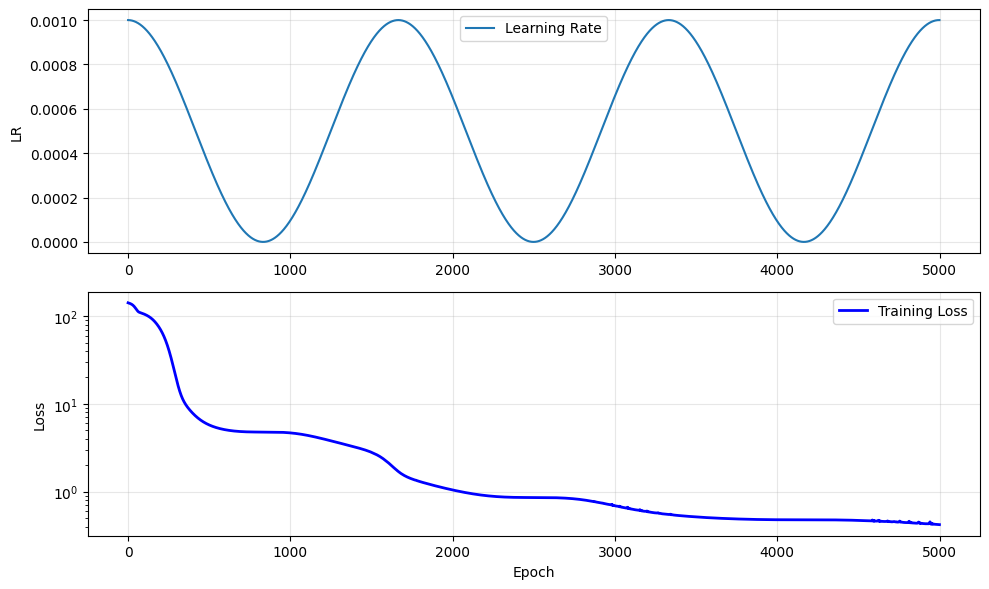

In [ ]:
# ============================================================
# 3️⃣ Load Training Data
# ============================================================
df = pd.read_csv('train.csv')

x = df[['y', 'z', 'phi', 'vy', 'vz', 'omega']].values
u = df[['ul', 'ur']].values
x_next = df[['y_next', 'z_next', 'phi_next', 'vy_next', 'vz_next', 'omega_next']].values

xu = np.concatenate([x, u], axis=1)
dx = (x_next - x) / 0.01  # approximate derivatives (Δx/Δt)

X_train = torch.tensor(xu, dtype=torch.float32)
dX_train = torch.tensor(dx, dtype=torch.float32)

# ============================================================
# 4️⃣ Load Test Data
# ============================================================
df_test = pd.read_csv('test.csv')

x_test = df_test[['y', 'z', 'phi', 'vy', 'vz', 'omega']].values
u_test = df_test[['ul', 'ur']].values
x_next_test = df_test[['y_next', 'z_next', 'phi_next', 'vy_next', 'vz_next', 'omega_next']].values

xu_test = np.concatenate([x_test, u_test], axis=1)
dx_test = (x_next_test - x_test) / 0.01

X_test = torch.tensor(xu_test, dtype=torch.float32)
dX_test = torch.tensor(dx_test, dtype=torch.float32)

# ============================================================
# 5️⃣ Training Setup
# ============================================================
lr = 0.001
num_epochs = 5000
T_scheduler = num_epochs // 6
device = "cpu"
loss_fun = nn.MSELoss()

model_nn = Model().to(device)
optim = torch.optim.Adam(model_nn.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optim, T_scheduler)

# Move data to device
X_train = X_train.to(device)
dX_train = dX_train.to(device)
X_test = X_test.to(device)
dX_test = dX_test.to(device)

# ============================================================
# 6️⃣ Training Loop
# ============================================================
lrs = []
losses = []
start_time = time.time()

for epoch in range(num_epochs):
    model_nn.train()
    optim.zero_grad()

    # Split input into x (state) and u (control)
    x_train = X_train[:, :6]
    u_train = X_train[:, 6:]

    # Forward pass
    x_dot_pred = model_nn(x_train, u_train)

    # Compute loss (data-driven)
    loss = loss_fun(x_dot_pred, dX_train)

    # Backpropagation
    loss.backward()
    optim.step()
    scheduler.step()

    lrs.append(scheduler.get_last_lr()[0])
    losses.append(loss.item())

    if (epoch + 1) % 200 == 0:
        print(f"t={time.time() - start_time:.2f}s | Epoch {epoch + 1}/{num_epochs} | Loss={loss.item():.6f} | LR={scheduler.get_last_lr()[0]:.6f}")

print("✅ Training finished.")

# ============================================================
# 7️⃣ Plot Learning Curves
# ============================================================
plt.figure(figsize=(10, 6))

plt.subplot(2, 1, 1)
plt.plot(lrs, label='Learning Rate')
plt.ylabel('LR')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(2, 1, 2)
plt.plot(losses, label='Training Loss', color='blue', linewidth=2)
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.yscale('log')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


=== TEST EVALUATION ===

Data scale check:
dX_test mean: -1.515642
dX_test std: 63.780159
Interpretation: dX_test represents derivatives (dx/dt), using dX_pred = x_dot_nn
dX_pred_test mean: -1.074259
dX_pred_test std: 56.316586

Test Data Loss (L_d): 99.276863
Test Physics Loss (L_ph): 3156.495850
Test Total Loss: 3255.772705

State-wise Mean Absolute Errors:
  Δy: 1.258522
  Δz: 1.146210
  Δphi: 0.217678
  Δvy: 9.432160
  Δvz: 10.600708
  Δomega: 3.848882

=== PREDICTION VISUALIZATION ===


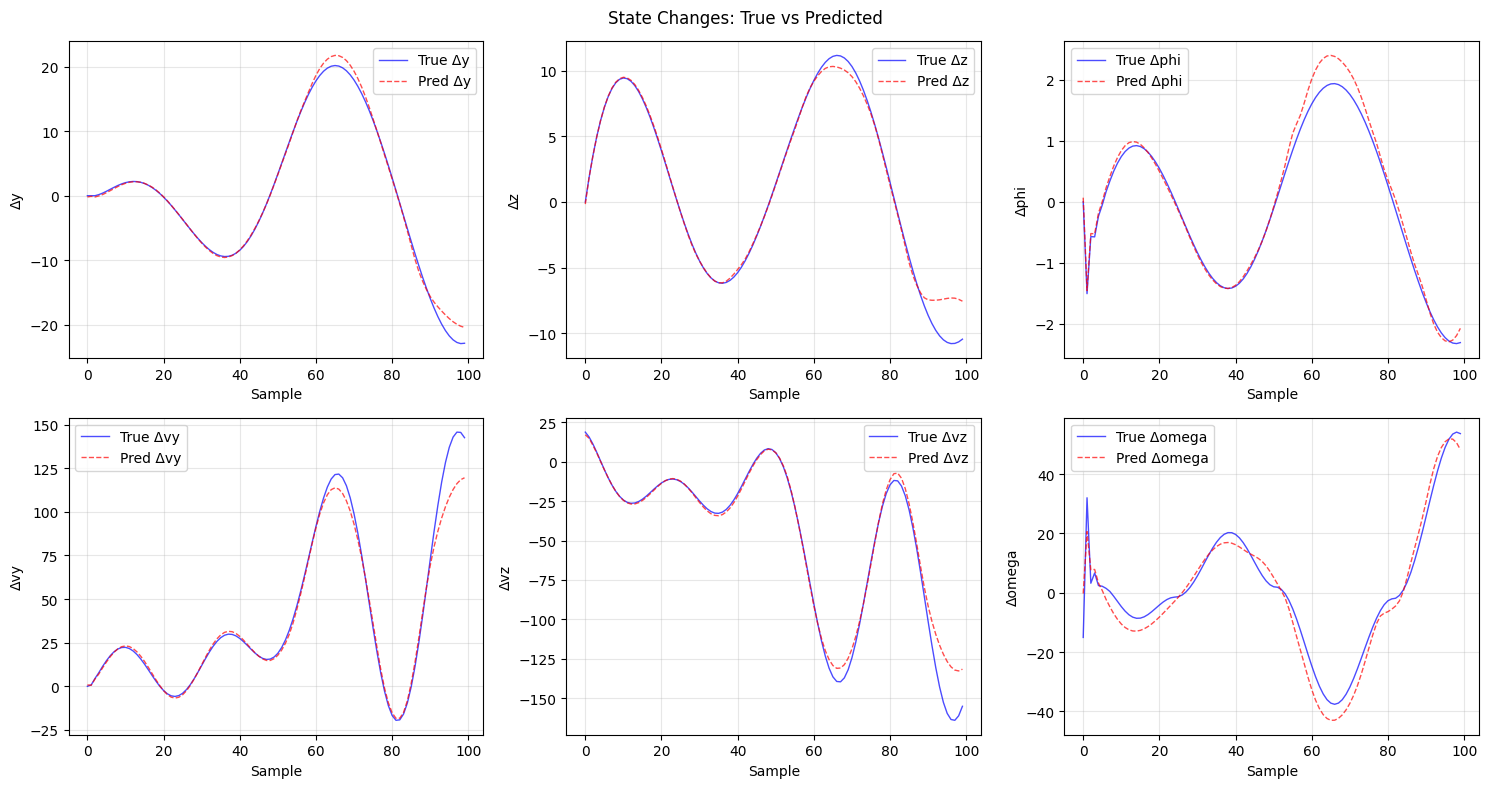

In [ ]:
# Test evaluation
coeff_phys = 1.0
print("\n=== TEST EVALUATION ===")
model_nn.eval()
with torch.no_grad():
    # Split test input
    x_k_test = X_test[:, :6]  # State variables (first 6 columns)
    u_k_test = X_test[:, 6:]  # Control inputs

    # Predictions (✅ FIXED)
    x_dot_nn_test = model_nn(x_k_test, u_k_test)

    # Data scale check
    print(f"\nData scale check:")
    print(f"dX_test mean: {dX_test.mean().item():.6f}")
    print(f"dX_test std: {dX_test.std().item():.6f}")

    # Check if dX_test represents state changes or derivatives
    if abs(dX_test.mean().item()) < 0.1:  # If dX_test is small, it's likely state changes
        dX_pred_test = x_dot_nn_test * dt
        print("Interpretation: dX_test represents state changes (Δx), using dX_pred = x_dot_nn * dt")
    else:  # If dX_test is large, it's likely derivatives
        dX_pred_test = x_dot_nn_test
        print("Interpretation: dX_test represents derivatives (dx/dt), using dX_pred = x_dot_nn")

    print(f"dX_pred_test mean: {dX_pred_test.mean().item():.6f}")
    print(f"dX_pred_test std: {dX_pred_test.std().item():.6f}")

    # Test losses
    test_loss_d = loss_fun(dX_pred_test, dX_test)
    x_dot_anlyt_test = f_anlyt(x_k_test, u_k_test)
    test_loss_ph = loss_fun(x_dot_nn_test, x_dot_anlyt_test)
    test_loss_total = test_loss_d + coeff_phys * test_loss_ph

    print(f"\nTest Data Loss (L_d): {test_loss_d.item():.6f}")
    print(f"Test Physics Loss (L_ph): {test_loss_ph.item():.6f}")
    print(f"Test Total Loss: {test_loss_total.item():.6f}")

    # State-wise errors
    state_errors = torch.abs(dX_pred_test - dX_test).mean(dim=0)
    state_names = ['Δy', 'Δz', 'Δphi', 'Δvy', 'Δvz', 'Δomega']
    print("\nState-wise Mean Absolute Errors:")
    for i, name in enumerate(state_names):
        print(f"  {name}: {state_errors[i].item():.6f}")

# Compare predictions vs true
print("\n=== PREDICTION VISUALIZATION ===")
with torch.no_grad():
    n_vis = min(100, X_test.shape[0])

    # Split visualization data (✅ FIXED)
    x_vis = X_test[:n_vis, :6]
    u_vis = X_test[:n_vis, 6:]

    # Get predictions
    x_dot_nn_vis = model_nn(x_vis, u_vis)

    if abs(dX_test.mean().item()) < 0.1:
        dx_pred_vis = x_dot_nn_vis * dt
    else:
        dx_pred_vis = x_dot_nn_vis

    dx_true_vis = dX_test[:n_vis].cpu().numpy()
    dx_pred_vis = dx_pred_vis.cpu().numpy()

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    state_names = ['y', 'z', 'phi', 'vy', 'vz', 'omega']

    for i, ax in enumerate(axes.flat):
        if i < 6:
            ax.plot(dx_true_vis[:, i], 'b-', alpha=0.7, label='True Δ' + state_names[i], linewidth=1)
            ax.plot(dx_pred_vis[:, i], 'r--', alpha=0.7, label='Pred Δ' + state_names[i], linewidth=1)
            ax.set_xlabel('Sample')
            ax.set_ylabel(f'Δ{state_names[i]}')
            ax.legend()
            ax.grid(True, alpha=0.3)

    plt.suptitle('State Changes: True vs Predicted')
    plt.tight_layout()
    plt.show()


In [ ]:
# =================== TEST & EVALUATION ===================
model_nn.eval()
dt = 0.01  # time step

with torch.no_grad():
    # Split test input into states and controls
    x_k_test = X_test[:, :6]  # state variables (y, z, phi, vy, vz, omega)
    u_k_test = X_test[:, 6:]  # control inputs (ul, ur)

    # Prediction with PINN (Neural Network)
    x_dot_nn_test = model_nn(x_k_test, u_k_test)  # NN predicts derivatives
    dX_pred_nn = x_dot_nn_test  # model predicts derivatives directly

    # Prediction using analytical model
    x_dot_anlyt_test = f_anlyt(x_k_test, u_k_test)
    dX_pred_anlyt = x_dot_anlyt_test

    # Overall MSE
    mse_nn = loss_fun(dX_pred_nn, dX_test)
    mse_anlyt = loss_fun(dX_pred_anlyt, dX_test)

    print(f"MSE (PINN): {mse_nn.item():.8f}")
    print(f"MSE (Analytical Model): {mse_anlyt.item():.8f}")

    # Performance comparison for each state component individually
    state_names = ['y', 'z', 'phi', 'vy', 'vz', 'omega']
    print("\n--- MSE by state components ---")
    for i in range(6):
        mse_nn_comp = loss_fun(dX_pred_nn[:, i], dX_test[:, i])
        mse_anlyt_comp = loss_fun(dX_pred_anlyt[:, i], dX_test[:, i])
        print(f"d{state_names[i]}/dt | PINN: {mse_nn_comp.item():.8f} | Analytical: {mse_anlyt_comp.item():.8f}")


MSE (PINN): 99.27686310
MSE (Analytical Model): 4053.61694336

--- MSE by state components ---
dy/dt | PINN: 23.59109116 | Analytical: 260.47238159
dz/dt | PINN: 5.78116894 | Analytical: 47.16447449
dphi/dt | PINN: 0.41677856 | Analytical: 2.85861373
dvy/dt | PINN: 256.53906250 | Analytical: 9995.51953125
dvz/dt | PINN: 286.78939819 | Analytical: 12588.41406250
domega/dt | PINN: 22.54366493 | Analytical: 1427.27148438
